# 1) Load data
- pd.read ..
- check dtypes, shape and head
- col hygene: df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
- datetime: pd.to_datetime(df["date]) or df.set_index("date") + df = df.sort_values('date')
- df.describe ...
- check na and fill or not
- check duplicates:  dup = df.duplicated().sum() + df.drop_duplicates(subset=[...])
- check unique values per col
- check value_counts per col
- quick outlier check using iqr: for c in df.select_dtypes(np.number):
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(c, df.loc[(df[c] < q1-3*iqr)|(df[c] > q3+3*iqr), c].count(), "outliers") #here we use factor 3 but people usually use 1.5 !
- study Y: 
    y = df["y"]
    print(y.describe())
    sns.histplot(y, kde=True)
- memory: df.info(memory_usage='deep')
- start with a random seed: 
    RANDOM_STATE = 42
    np.random.seed(RANDOM_STATE)


# 2) EDA

- Plot of all distribution
- scatter plot 
- (X, Y) plot
- plot all rows and color the point depending on the label (create one if it's a regression using bins) to try and see what specific feature change made two points have different labels when the rest of the features were similar.
- features and class imbalance
- Heatmap
- VIF, To anticipate regression problems, compute Variance Inflation Factor (VIF)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_num = df.select_dtypes(np.number).drop(columns=['y'])
    vif = pd.Series(
        [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])],
        index=X_num.columns
    )
    print(vif.sort_values(ascending=False))

- ACF/PACF
- stationarity with ADF
- Shapiro for gaussianity
- Granger causality
- Feature importance ? shapley val ? some kind of grouped analysis
- PCA plot between X and Y (try t-sne and UMAP)
- look for clusters (unsupervised learning)
- groupby summaries
- Explainability	Permutation, SHAP	sklearn, shap	Model interpretability
- Dimensionality	PCA, t-SNE, UMAP	sklearn, umap	Visual separability
- Unsupervised	KMeans, DBSCAN	sklearn.cluster	Regime discovery
- Target relationships
Mutual info, correlations
sklearn.feature_selection
Nonlinear relevance


# 3)

- encode categorical var
- standard scale
- impute/fill
- transform the data
- polynomial expansion

Load & sanity checks — pandas (read_csv, dtypes, nulls, unique counts).

EDA — seaborn/matplotlib; correlations, distributions, groupby summaries; if time-based: ADF, ACF/PACF (statsmodels).

Preprocess — ColumnTransformer with OneHotEncoder + StandardScaler (numeric), imputation; optional PowerTransformer/np.log1p, polynomial features.

Baseline models — OLS/Ridge/Lasso/ElasticNet for regression; Logistic/SVC/RF/XGB for classification. Use Pipeline.

CV & tuning — GridSearchCV/RandomizedSearchCV; TimeSeriesSplit if using date.

Diagnostics — residual plots, Jarque–Bera / Breusch–Pagan / DW / Ljung–Box (statsmodels), feature importances, permutation importance.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('drw_practice_Xy.csv')
df.shape
df.head()
df.describe()

print(df["school_score"].value_counts())
print(df.isna().sum(axis=0))
df.fillna(0, inplace=True)
for col in df.columns:
    print(col, df[col].nunique(), end="\t")
df.dtypes

for col in df.select_dtypes(np.number):
    z_score = ((df[col] - df[col].mean())/df[col].std()).abs() > 3
    print(col, np.sum(z_score), end="\t")

for c in df.select_dtypes(np.number):
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(c, df.loc[(df[c] < q1-3*iqr)|(df[c] > q3+3*iqr), c].count(), "outliers")


school_score
7     94
6     77
8     49
5     37
9     26
4     25
3      6
10     6
Name: count, dtype: int64
date              0
neighborhood      0
sqft              0
bedrooms          0
bathrooms         0
age_years         0
dist_center_km    0
school_score      0
lot_size_m2       0
has_garage        0
y                 0
dtype: int64
date 320	neighborhood 4	sqft 285	bedrooms 4	bathrooms 6	age_years 260	dist_center_km 269	school_score 8	lot_size_m2 254	has_garage 2	y 316	sqft 0	bedrooms 2	bathrooms 6	age_years 0	dist_center_km 7	school_score 0	lot_size_m2 0	has_garage 0	y 1	sqft 0 outliers
bedrooms 0 outliers
bathrooms 61 outliers
age_years 0 outliers
dist_center_km 5 outliers
school_score 0 outliers
lot_size_m2 0 outliers
has_garage 0 outliers
y 0 outliers


In [ ]:
import seaborn as sns

y = df["y"]
print(y.describe())
sns.histplot(y, kde=True)


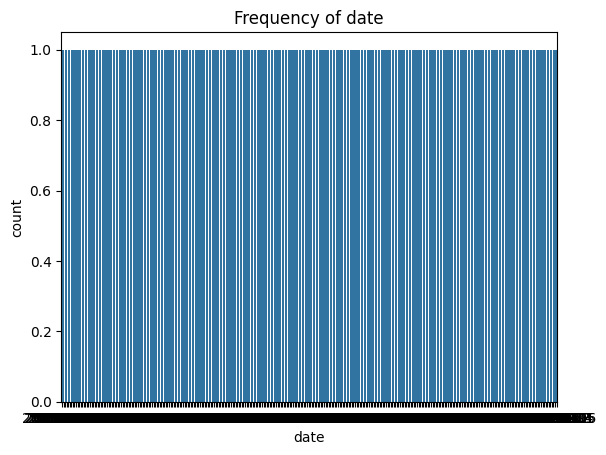

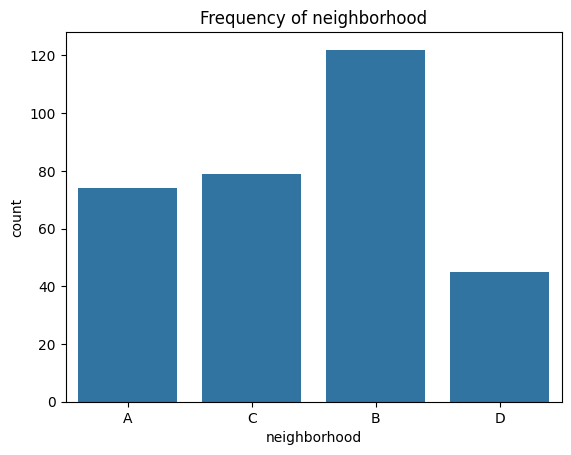

In [55]:
import matplotlib.pyplot as plt

for col in df.select_dtypes('object'):
    sns.countplot(x=df[col])
    plt.title(f"Frequency of {col}")
    plt.show()

In [ ]:
df["y"].kurtosis(), df["y"].skew() # -> if skew > 0 --> mediane < moyennne

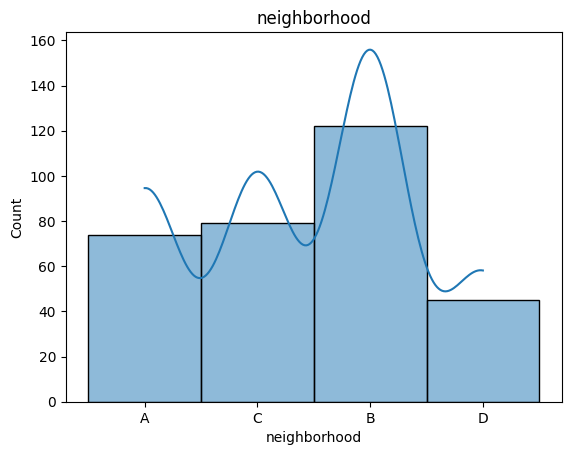

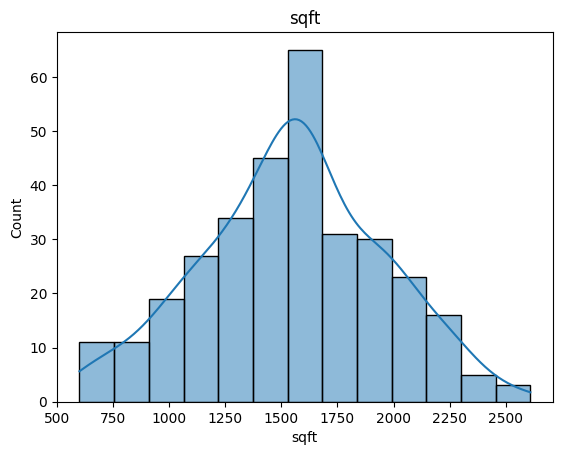

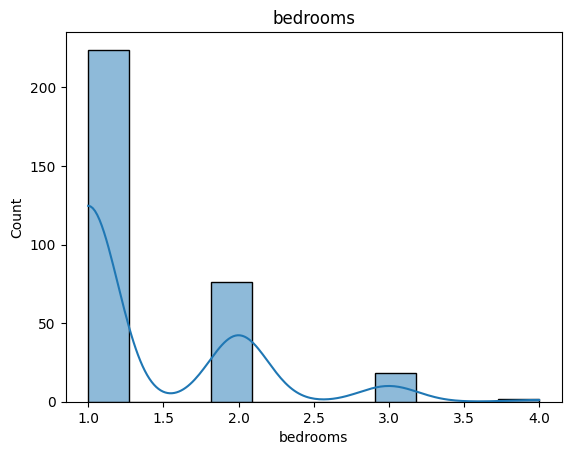

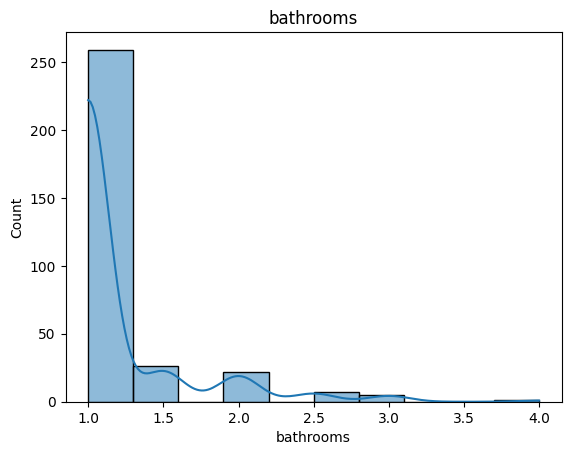

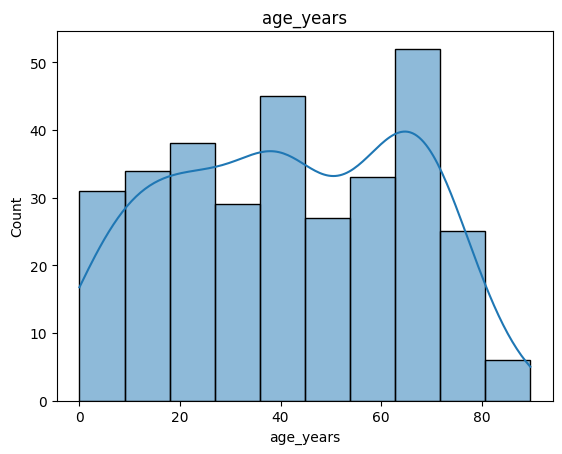

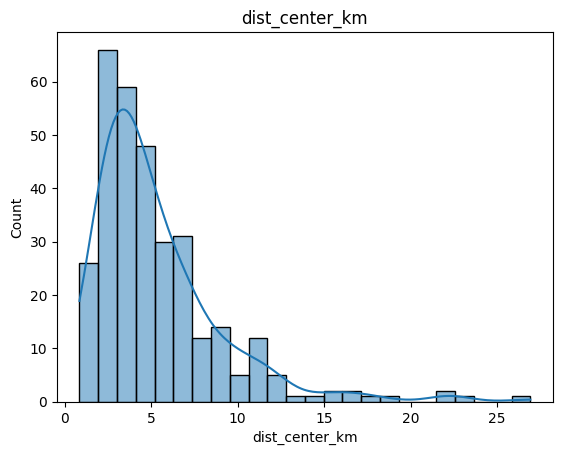

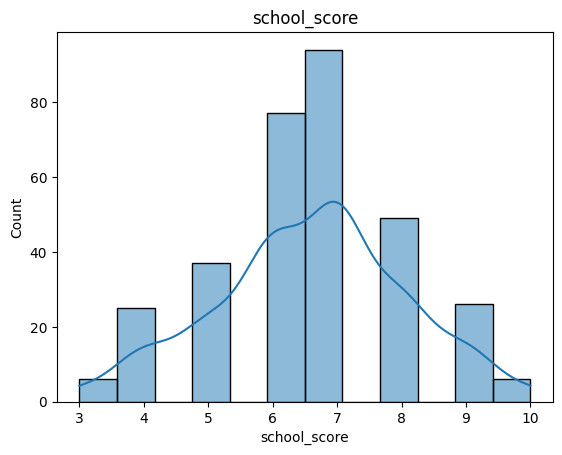

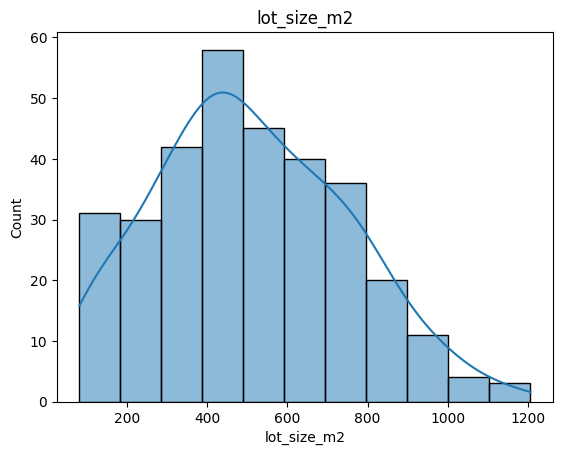

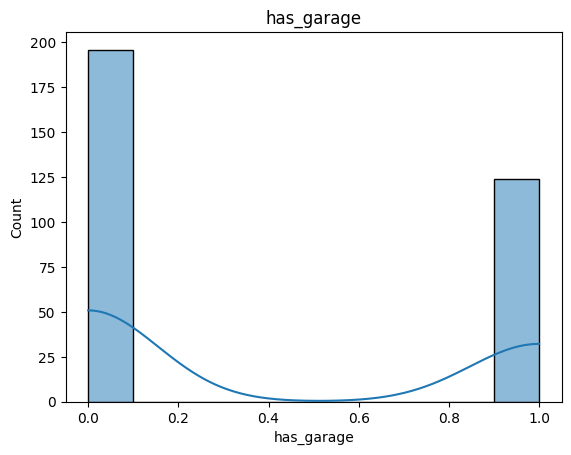

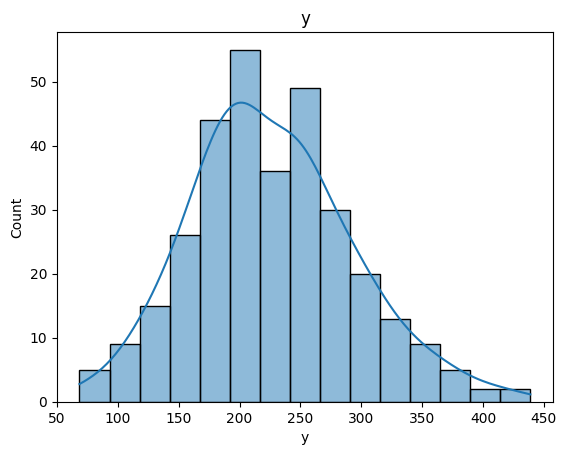

In [31]:
import matplotlib.pyplot as plt 

for col in df.iloc[:,1:]:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

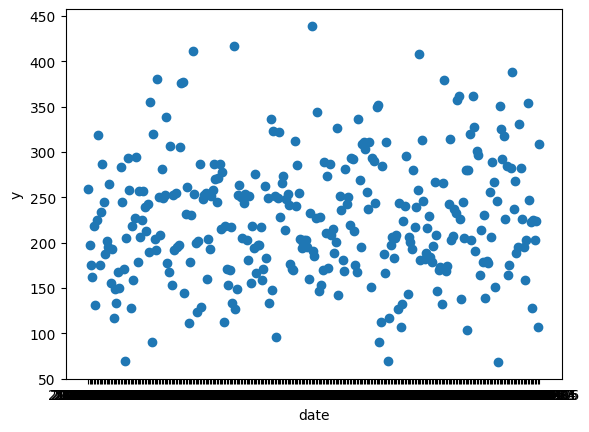

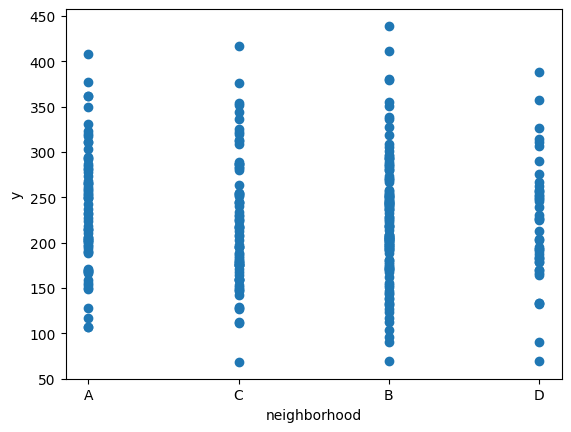

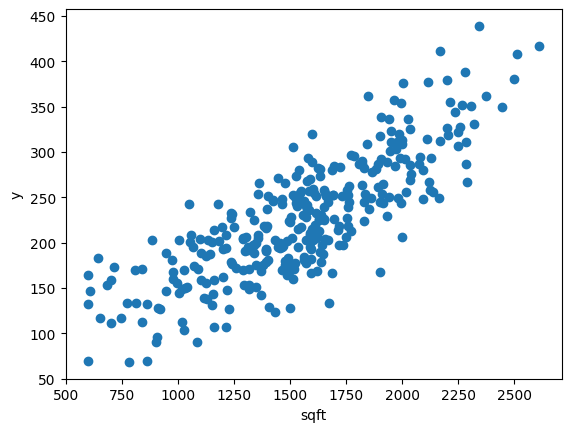

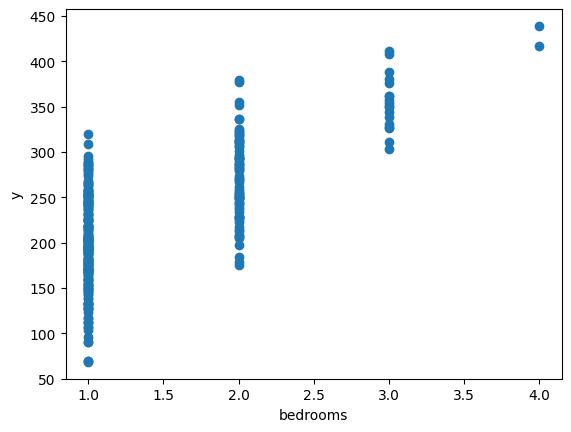

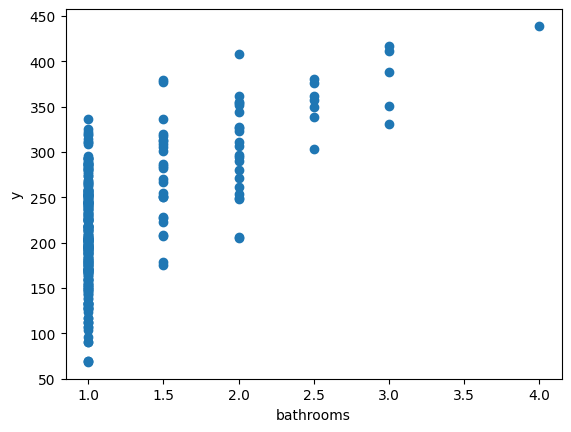

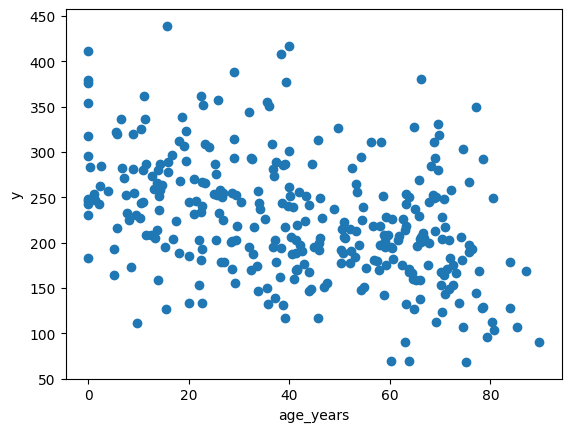

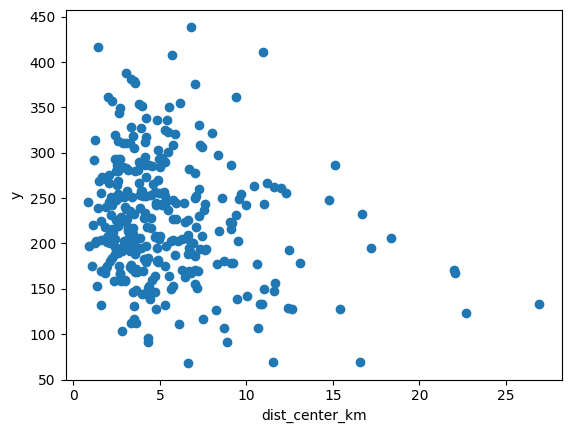

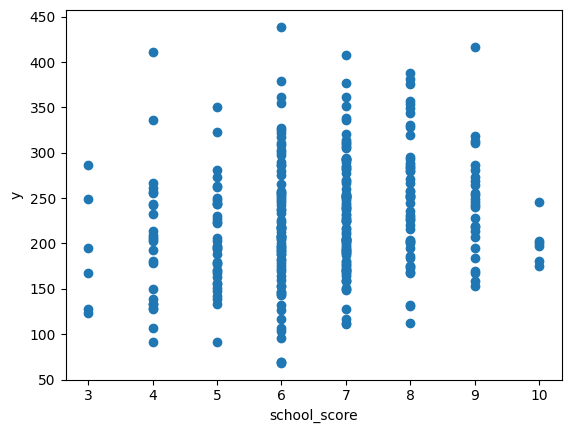

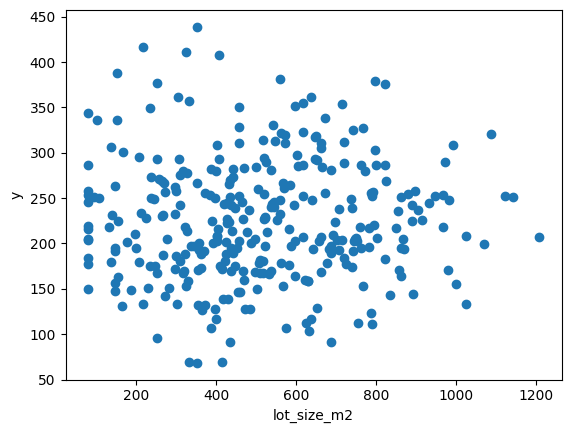

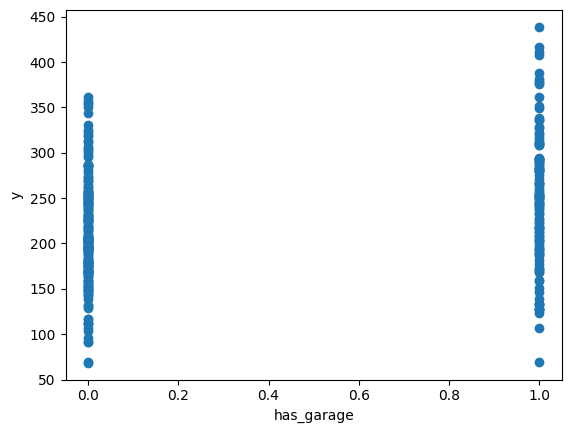

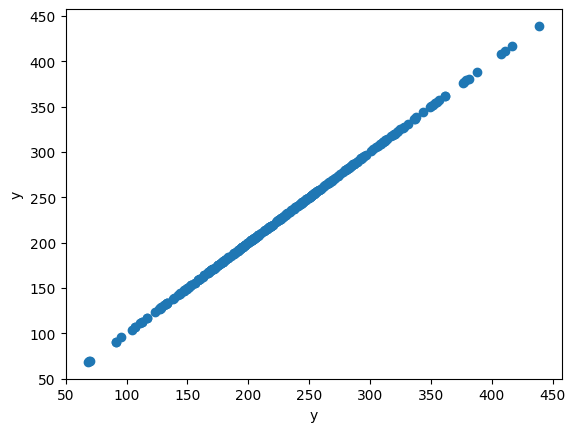

In [34]:
for col in df:
    plt.scatter(df[col], df["y"])
    plt.xlabel(col)
    plt.ylabel("y")
    plt.show()

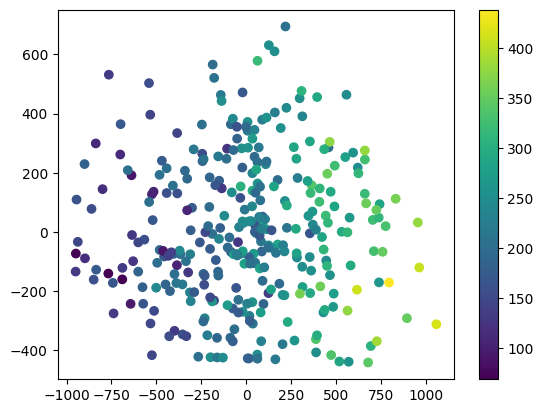

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(df.select_dtypes(exclude='object').drop(columns=["y"]))
X_reduced.shape
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df["y"])
plt.colorbar()

Text(0, 0.5, 'y')

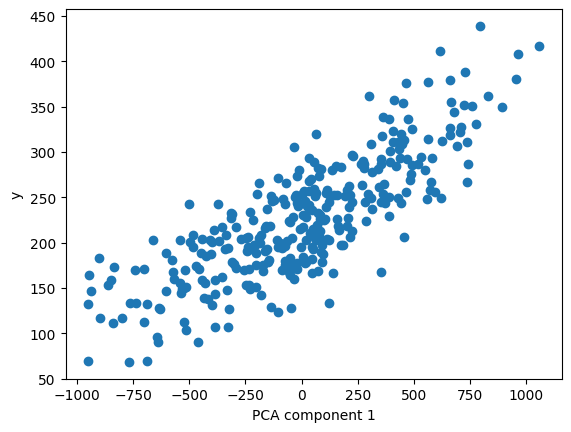

In [46]:
pca = PCA(n_components=1)
X_reduced = pca.fit_transform(df.select_dtypes(exclude='object').drop(columns=["y"]))
plt.plot(X_reduced, df["y"], 'o')
plt.xlabel("PCA component 1")
plt.ylabel("y")


In [ ]:
df.select_dtypes(exclude='object').corr()

,sqft,bedrooms,bathrooms,age_years,dist_center_km,school_score,lot_size_m2,has_garage,y
sqft,1.000000,0.646265,0.531534,-0.003608,-0.014587,0.045209,0.022206,0.175022,0.816319
bedrooms,0.646265,1.000000,0.827425,-0.002148,-0.030996,0.069379,-0.045286,0.230945,0.697276
bathrooms,0.531534,0.827425,1.000000,-0.063647,0.031478,0.018877,-0.009902,0.157138,0.611151
age_years,-0.003608,-0.002148,-0.063647,1.000000,-0.005411,-0.035427,0.058465,-0.052519,-0.400672
dist_center_km,-0.014587,-0.030996,0.031478,-0.005411,1.000000,-0.656052,-0.007252,-0.011210,-0.205783
school_score,0.045209,0.069379,0.018877,-0.035427,-0.656052,1.000000,-0.035435,-0.018386,0.197348
lot_size_m2,0.022206,-0.045286,-0.009902,0.058465,-0.007252,-0.035435,1.000000,-0.026893,0.026413
has_garage,0.175022,0.230945,0.157138,-0.052519,-0.011210,-0.018386,-0.026893,1.000000,0.259986
y,0.816319,0.697276,0.611151,-0.400672,-0.205783,0.197348,0.026413,0.259986,1.000000


<Axes: >

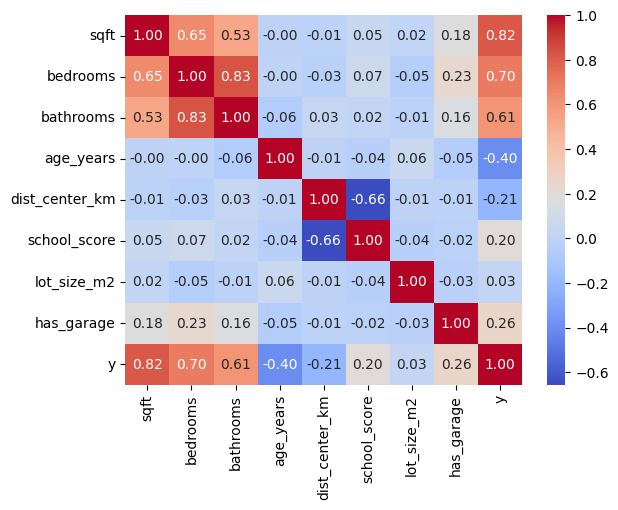

In [ ]:
sns.heatmap(df.select_dtypes(exclude='object').corr(), annot=True, fmt=".2f", cmap="coolwarm")

<Axes: >

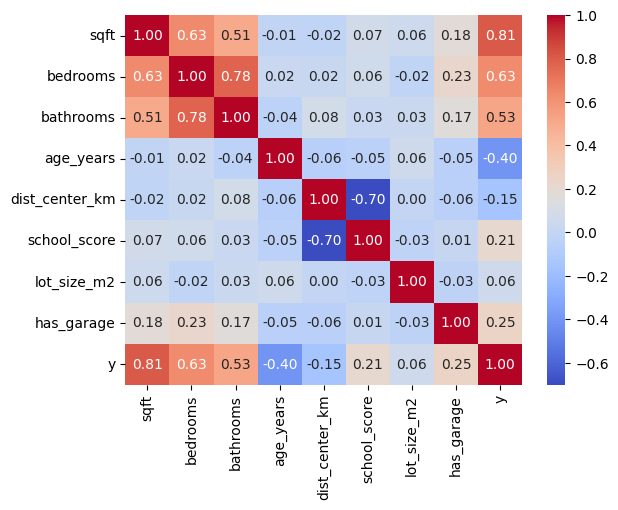

In [56]:
sns.heatmap(df.select_dtypes(exclude='object').corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm")

In [52]:
from scipy.stats import shapiro
stat, p = shapiro(df["y"])
print('Statistics=%.3f, p=%.3f' % (stat, p))
alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Statistics=0.990, p=0.023
Sample does not look Gaussian (reject H0)


In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = df.select_dtypes(np.number).drop(columns=['y'])
vif = pd.Series(
    [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])],
    index=X_num.columns
)
print(vif.sort_values(ascending=False))


bathrooms         25.837014
sqft              24.035311
bedrooms          23.487456
school_score      12.638552
lot_size_m2        5.187827
age_years          3.944165
dist_center_km     3.134208
has_garage         1.730701
dtype: float64


In [58]:
# regression of the bathrooms on the other numerical features
import statsmodels.api as sm
X = df.select_dtypes(np.number).drop(columns=['y', 'bathrooms'])
y = df['bathrooms']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              bathrooms   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     101.2
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           2.07e-76
Time:                        15:32:03   Log-Likelihood:                -3.3439
No. Observations:                 320   AIC:                             22.69
Df Residuals:                     312   BIC:                             52.83
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3852      0.121      3.

Text(0.5, 1.0, 'Target over time')

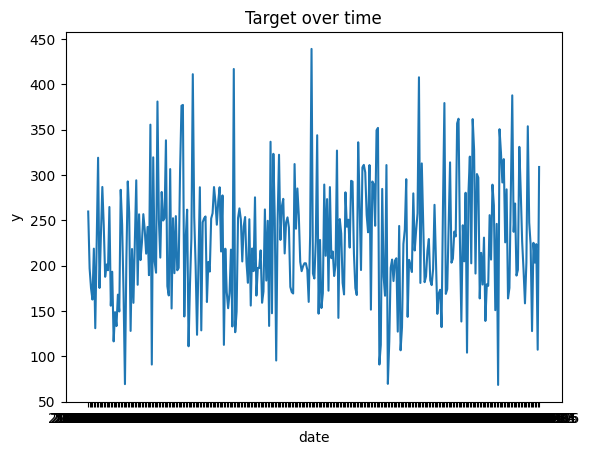

In [59]:
df = df.sort_values("date")
sns.lineplot(x="date", y="y", data=df)
plt.title("Target over time")

In [60]:
from statsmodels.tsa.stattools import adfuller
adf_stat, adf_p, *_ = adfuller(df["y"])
print(f"ADF p={adf_p:.3f}")


ADF p=0.000


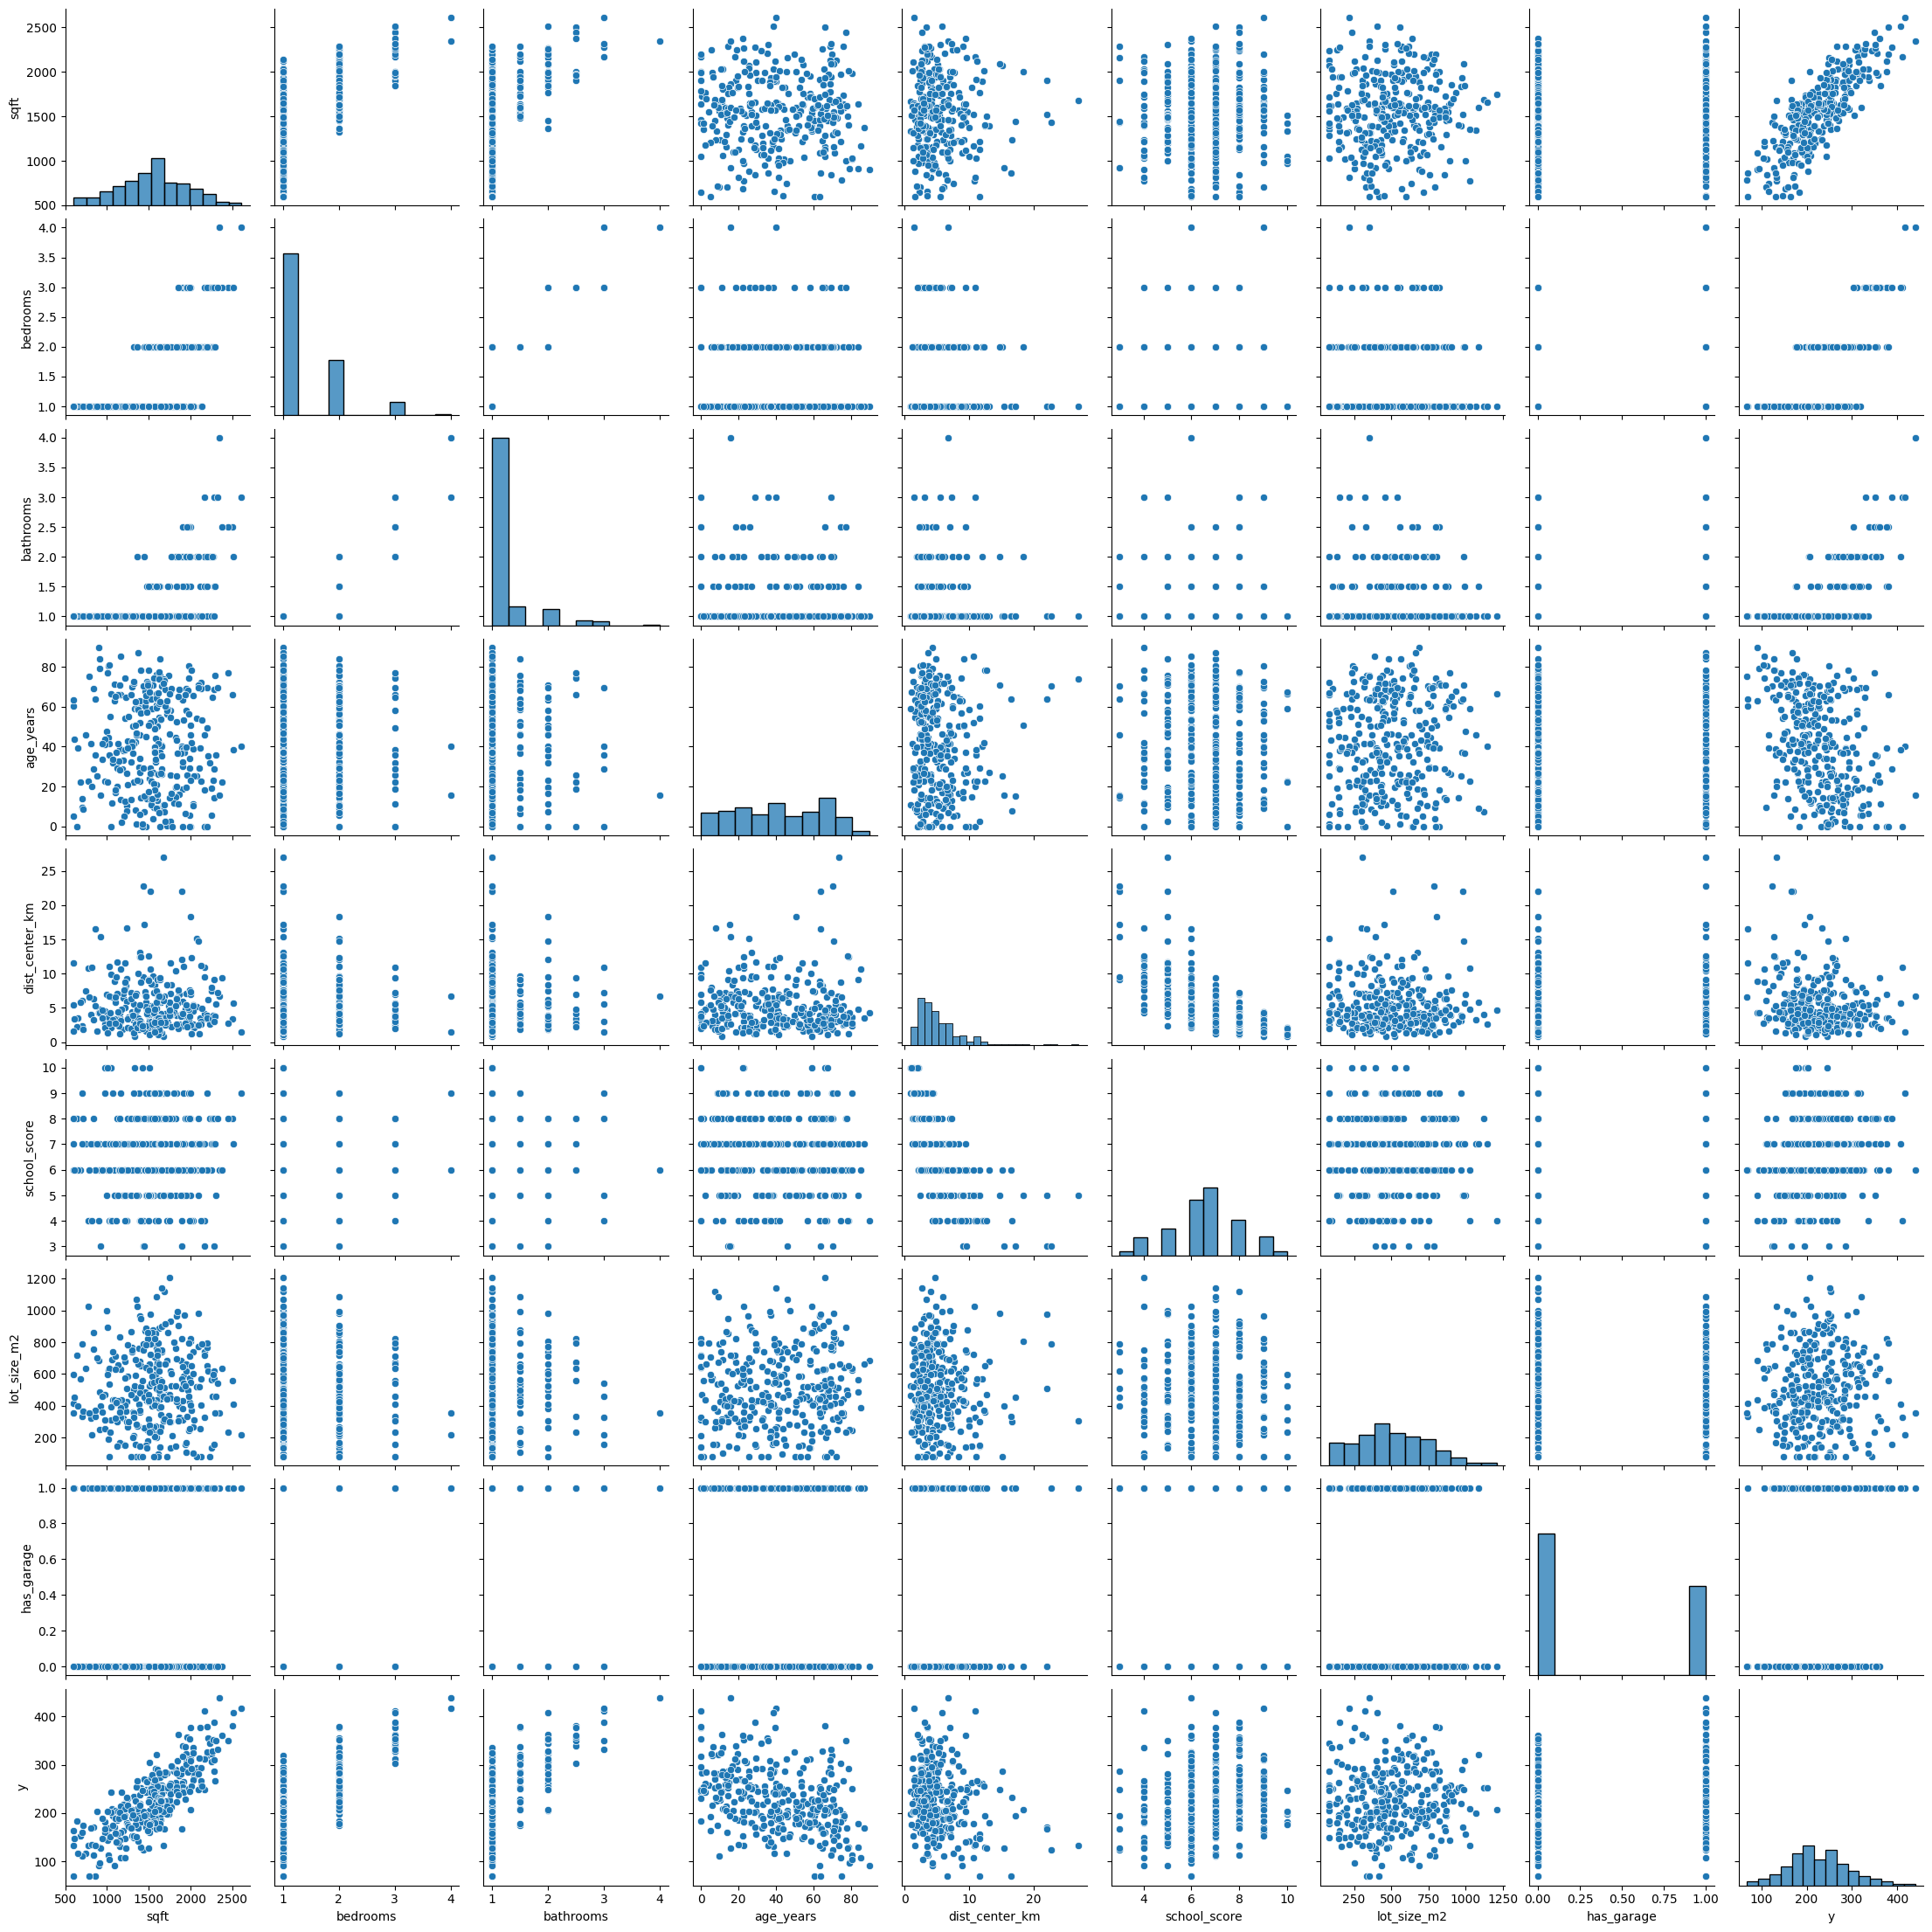

In [61]:
sns.pairplot(df.select_dtypes(np.number))


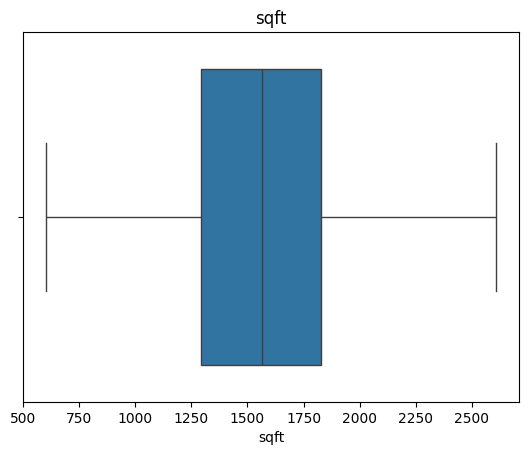

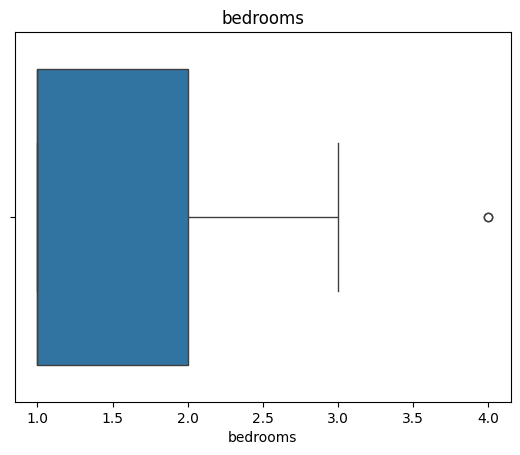

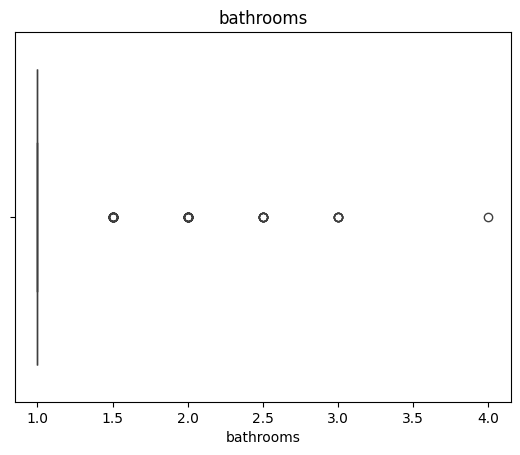

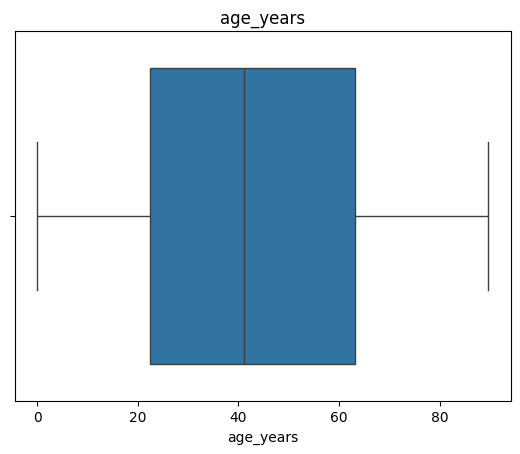

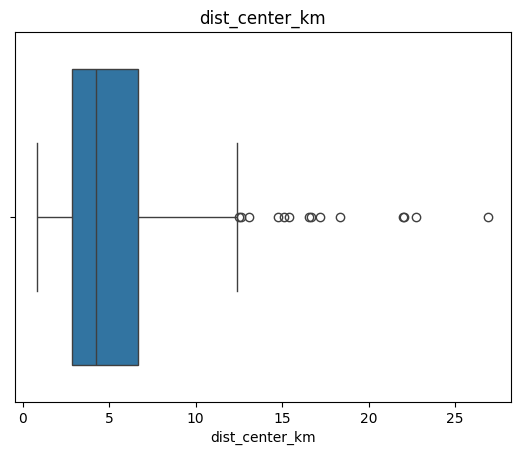

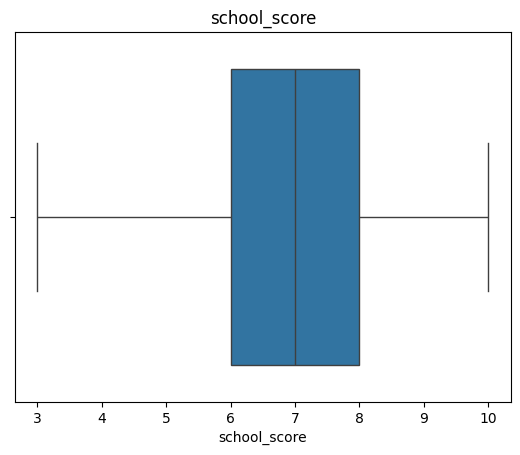

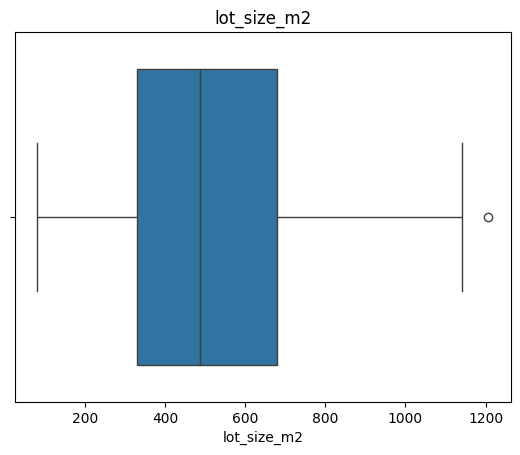

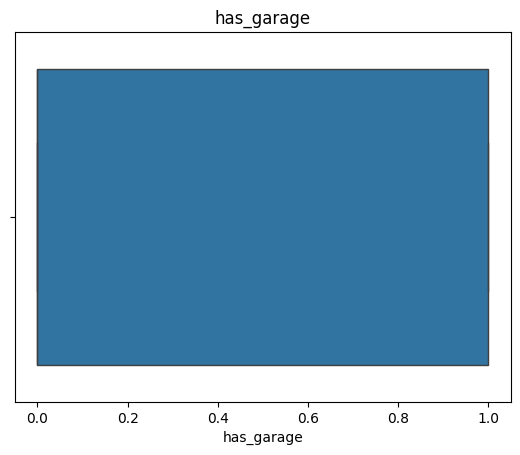

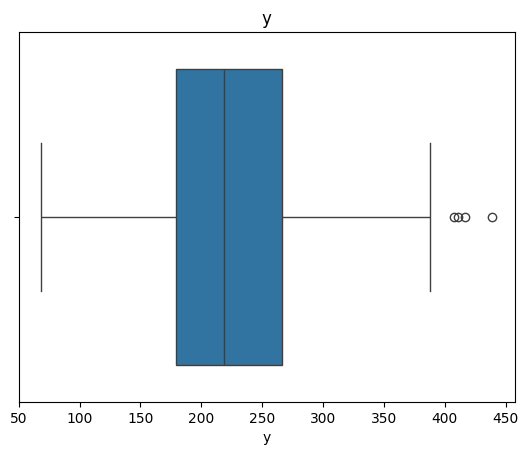

In [62]:
for col in df.select_dtypes(np.number).columns:
    sns.boxplot(x=df[col]); plt.title(col); plt.show()

<Axes: >

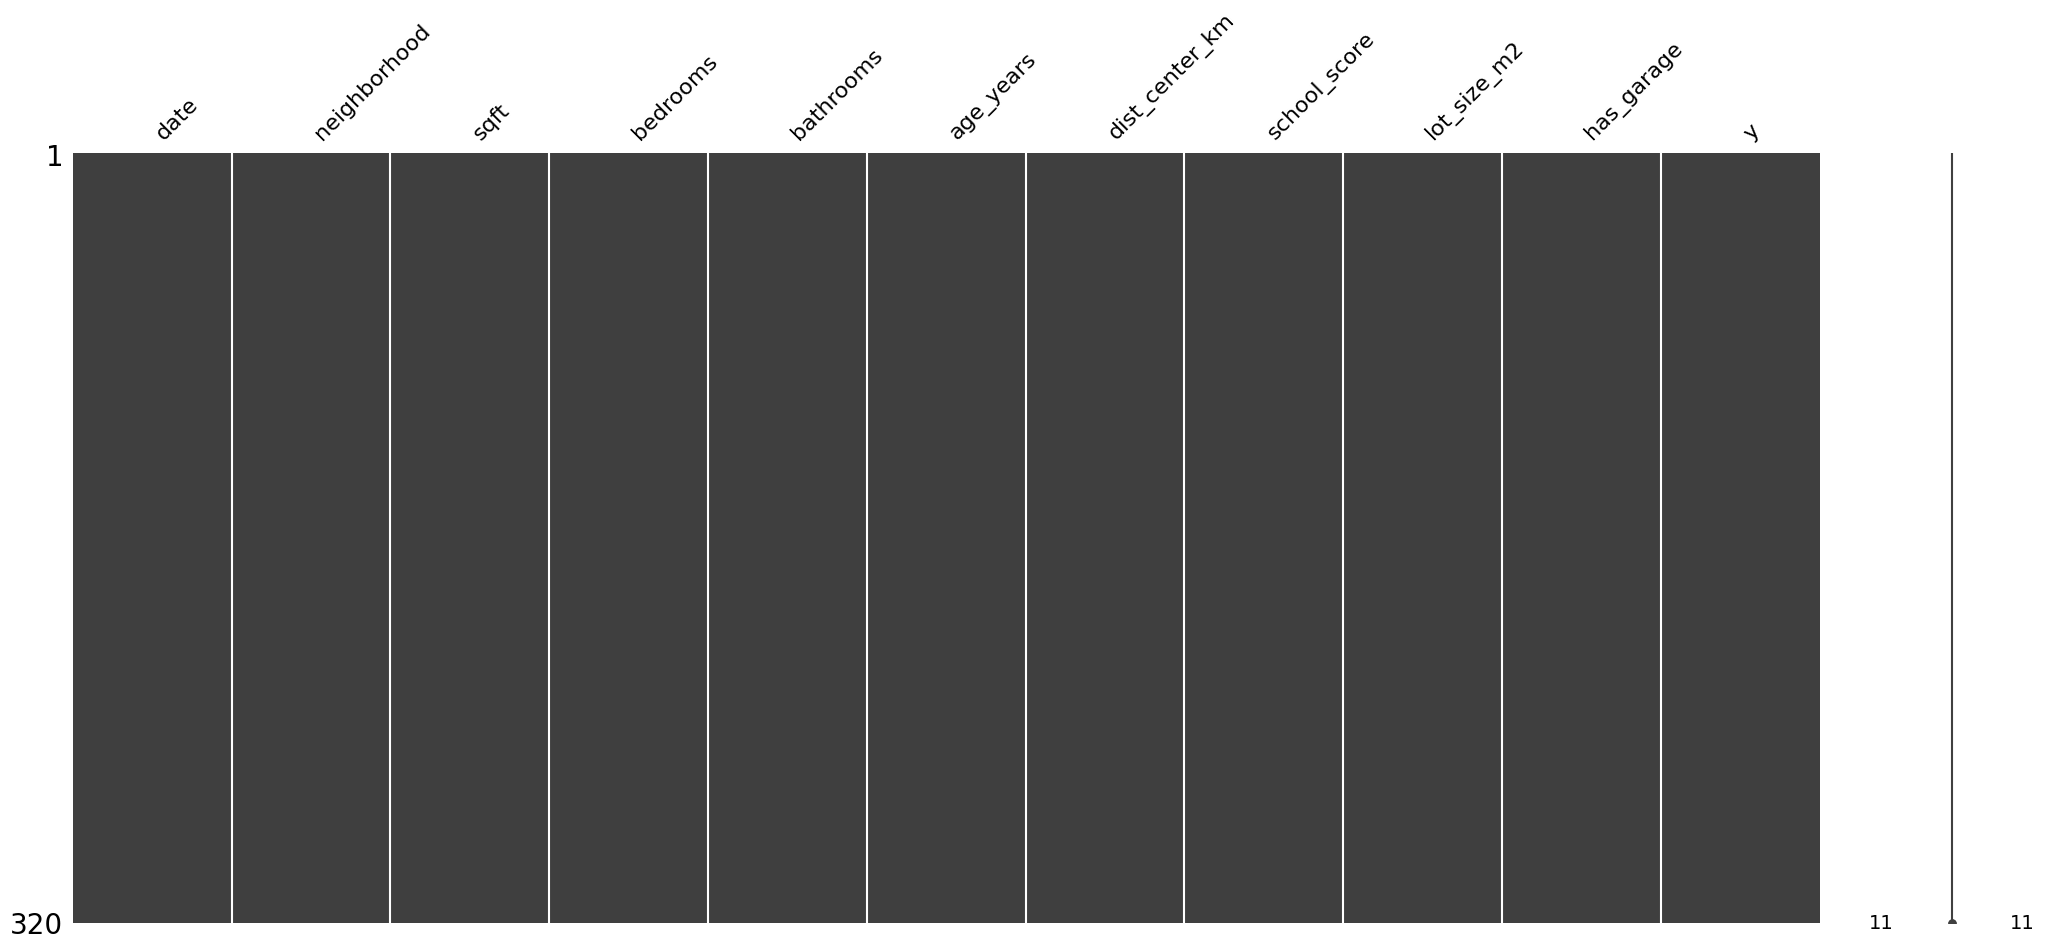

In [64]:
import missingno as msno
msno.matrix(df)

In [65]:
from sklearn.feature_selection import mutual_info_regression
X = df.select_dtypes(np.number).drop(columns='y')
mi = pd.Series(mutual_info_regression(X, df['y'], random_state=0), index=X.columns)
mi.sort_values(ascending=False)


sqft              0.530262
bedrooms          0.319292
bathrooms         0.207045
age_years         0.113724
dist_center_km    0.081796
has_garage        0.065763
lot_size_m2       0.025557
school_score      0.017519
dtype: float64

---

In [2]:
# =============================================================
# STEP 3 : PREPROCESSING & FEATURE ENGINEERING
# =============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -------------------------------------------------------------
# 1️⃣  Separate target and features
# -------------------------------------------------------------
target = "y"
X = df.drop(columns=[target])
y = df[target]

# Split now (so imputers/encoders fit only on train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# -------------------------------------------------------------
# 2️⃣  Identify column types
# -------------------------------------------------------------
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# -------------------------------------------------------------
# 3️⃣  Numeric pipeline
# -------------------------------------------------------------
# - Median imputation (robust to outliers)
# - Scaling (mean=0, std=1)
# - Optional polynomial features for non-linear terms
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    # uncomment if you want polynomial expansion
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

# -------------------------------------------------------------
# 4️⃣  Categorical pipeline
# -------------------------------------------------------------
# - Most-frequent imputation
# - One-Hot encoding
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# -------------------------------------------------------------
# 5️⃣  Combine everything
# -------------------------------------------------------------
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# -------------------------------------------------------------
# 6️⃣  Inspect transformed shape
# -------------------------------------------------------------
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre  = preprocess.transform(X_test)

print("Transformed shapes:", X_train_pre.shape, X_test_pre.shape)
print("Feature names:", preprocess.get_feature_names_out()[:10], "...")


Numeric columns: ['sqft', 'bedrooms', 'bathrooms', 'age_years', 'dist_center_km', 'school_score', 'lot_size_m2', 'has_garage']
Categorical columns: ['date', 'neighborhood']
Transformed shapes: (256, 304) (64, 304)
Feature names: ['num__sqft' 'num__bedrooms' 'num__bathrooms' 'num__age_years'
 'num__dist_center_km' 'num__school_score' 'num__lot_size_m2'
 'num__has_garage' 'num__sqft^2' 'num__sqft bedrooms'] ...


In [3]:
# Log transform skewed numeric features
for col in num_cols:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])

# Interaction terms
from sklearn.preprocessing import PolynomialFeatures
interaction = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
interaction_terms = interaction.fit_transform(df[num_cols])
interaction_df = pd.DataFrame(interaction_terms, columns=interaction.get_feature_names_out(num_cols))
df = pd.concat([df, interaction_df], axis=1)
print(df.shape)

(320, 47)


awesome — here’s a **drop-in modeling module** that plugs right after your preprocessing cell. It covers:

* **Regression:** OLS, RidgeCV, LassoCV, ElasticNetCV, **ARIMAX** (a.k.a. SARIMAX with exogenous (X)), **RandomForest**, **XGBoost**, **PyTorch MLP**, **PyTorch LSTM (TS)**
* **Classification:** Logistic (with L1/L2/EN via `saga`), SVC, **RandomForest**, **XGBoost**, **PyTorch MLP**, **PyTorch LSTM (TS)**
* Proper **time-series split** (no leakage), **early stopping** for XGB, and clean **metrics/plots**.

> Assumptions:
>
> * You already built `preprocess` and have `X_train, X_test, y_train, y_test` from your previous step.
> * Set the flags at the top: `TASK = "regression"` or `"classification"`, `IS_TIME_SERIES = True/False`, and provide `DATE_COL` if you want ARIMAX/LSTM.
> * If you don’t have PyTorch or xgboost installed, those blocks will be skipped gracefully.

---

## 🔧 Imports & flags (add if not already present)

```python
# ===========================
# MODELING: imports & config
# ===========================
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, KFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_recall_fscore_support, roc_auc_score)
from sklearn.inspection import permutation_importance

# Regression models
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Statsmodels (ARIMAX / SARIMAX)
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# XGBoost (optional)
try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# PyTorch (optional)
try:
    import torch, torch.nn as nn
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

# ======= flags =======
TASK = "regression"          # "regression" or "classification"
IS_TIME_SERIES = False       # True if data are time-ordered
DATE_COL = "date"            # if you have a datetime column
RANDOM_STATE = 42
```

---

## 🧪 Metrics helpers (regression + classification)

```python
def rmse(y_true, y_pred): return math.sqrt(mean_squared_error(y_true, y_pred))

def eval_reg(name, y_true, y_pred):
    m = {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }
    print(f"{name:12s} | RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  R2={m['R2']:.4f}")
    return m

def eval_cls(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    msg = f"{name:12s} | Acc={acc:.3f}  P/R/F1={p:.3f}/{r:.3f}/{f:.3f}"
    if (y_proba is not None) and (len(np.unique(y_true))==2):
        auc = roc_auc_score(y_true, y_proba)
        msg += f"  ROC-AUC={auc:.3f}"
    print(msg)
```

---

## 🧵 Time-series split & early-stopping validation

```python
def ts_tail_split(X, y, valid_frac=0.2):
    n = len(X)
    n_val = int(np.ceil(valid_frac*n))
    train_idx = np.arange(0, n-n_val)
    val_idx   = np.arange(n-n_val, n)
    return train_idx, val_idx
```

---

## 📈 REGRESSION: OLS / Ridge / Lasso / ElasticNet

```python
if TASK == "regression":
    print("\n=== REGRESSION BASELINES ===")
    # Pipelines assume you already built `preprocess`
    ols = Pipeline([("prep", preprocess), ("model", LinearRegression())])
    ols.fit(X_train, y_train)
    yhat_ols = ols.predict(X_test)
    eval_reg("OLS", y_test, yhat_ols)

    ridge = Pipeline([("prep", preprocess),
                      ("model", RidgeCV(alphas=np.logspace(-6,3,20), cv=5))])
    ridge.fit(X_train, y_train)
    yhat_ridge = ridge.predict(X_test)
    eval_reg("RidgeCV", y_test, yhat_ridge)

    lasso = Pipeline([("prep", preprocess),
                      ("model", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000))])
    lasso.fit(X_train, y_train)
    yhat_lasso = lasso.predict(X_test)
    eval_reg("LassoCV", y_test, yhat_lasso)

    enet = Pipeline([("prep", preprocess),
                     ("model", ElasticNetCV(l1_ratio=[0.1,0.5,0.9], cv=5, random_state=RANDOM_STATE, max_iter=10000))])
    enet.fit(X_train, y_train)
    yhat_enet = enet.predict(X_test)
    eval_reg("ElasticNetCV", y_test, yhat_enet)
```

---

## 🌲 REGRESSION: RandomForest & XGBoost (with early stopping)

```python
if TASK == "regression":
    # RandomForest
    rf_reg = Pipeline([("prep", preprocess),
                       ("model", RandomForestRegressor(n_estimators=600, min_samples_leaf=2,
                                                      random_state=RANDOM_STATE, n_jobs=-1))])
    rf_reg.fit(X_train, y_train)
    yhat_rf = rf_reg.predict(X_test)
    eval_reg("RF", y_test, yhat_rf)

    # XGBoost with early stopping on a val tail from TRAIN
    if HAS_XGB:
        # fit preprocess once to get fixed design matrices for ES split (avoid leakage)
        Xtr_all = preprocess.fit_transform(X_train)
        Xte = preprocess.transform(X_test)
        ytr_all = y_train.values

        tr_idx, val_idx = ts_tail_split(Xtr_all, ytr_all, valid_frac=0.2) if IS_TIME_SERIES else ts_tail_split(Xtr_all, ytr_all, valid_frac=0.2)
        X_tr, y_tr = Xtr_all[tr_idx], ytr_all[tr_idx]
        X_val, y_val = Xtr_all[val_idx], ytr_all[val_idx]

        xgb_reg = XGBRegressor(
            n_estimators=3000, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, reg_alpha=0.0, random_state=RANDOM_STATE, objective="reg:squarederror", n_jobs=-1, tree_method="hist"
        )
        xgb_reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="rmse", early_stopping_rounds=150, verbose=False)
        yhat_xgb = xgb_reg.predict(Xte)
        eval_reg("XGB-ES", y_test, yhat_xgb)
    else:
        print("[Info] xgboost not installed; skipping XGB.")
```

---

## 🧠 REGRESSION: ARIMAX (SARIMAX with exogenous features)

> Use this **only** for true time series, with date index and **past-only** exogenous features.

```python
if TASK == "regression" and IS_TIME_SERIES and DATE_COL in df.columns:
    print("\n=== ARIMAX (SARIMAX with exogenous X) ===")
    # Prepare exogenous design (use the same preprocess but ONLY numeric exog known at time t)
    df_ts = df.sort_values(DATE_COL).set_index(DATE_COL)
    # Align train/test by index used earlier
    tr_start, tr_end = X_train.index.min(), X_train.index.max()
    te_start, te_end = X_test.index.min(), X_test.index.max()

    # Build exog matrices using the same preprocess (fit on TRAIN to avoid leakage)
    Xtr_exog = preprocess.fit_transform(X_train)
    Xte_exog = preprocess.transform(X_test)

    # Fit ARIMAX on TRAIN (tune order by AIC or grid if time permits)
    # Start with a simple ARIMA(1,0,1); change as needed.
    arimax = SARIMAX(endog=y_train, exog=Xtr_exog, order=(1,0,1), enforce_stationarity=False, enforce_invertibility=False)
    arimax_fit = arimax.fit(disp=False)
    yhat_arimax = arimax_fit.predict(start=y_test.index[0], end=y_test.index[-1], exog=Xte_exog)
    eval_reg("ARIMAX(1,0,1)", y_test, yhat_arimax.values)
```

---

## 🧬 REGRESSION: PyTorch MLP (shallow NN)

```python
if TASK == "regression" and HAS_TORCH:
    print("\n=== Torch MLP (regression) ===")
    Xtr = preprocess.fit_transform(X_train)
    Xte = preprocess.transform(X_test)
    ytr = y_train.values.astype(np.float32).reshape(-1,1)

    class MLPReg(nn.Module):
        def __init__(self, in_dim, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1)
            )
        def forward(self, x): return self.net(x)

    model = MLPReg(Xtr.shape[1], hidden=64)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # L2 regularization
    loss_fn = nn.MSELoss()

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32))
    ytr_t = torch.from_numpy(ytr)
    for epoch in range(250):
        model.train(); opt.zero_grad()
        pred = model(Xtr_t); loss = loss_fn(pred, ytr_t)
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        yhat = model(torch.from_numpy(Xte.astype(np.float32))).numpy().ravel()
    eval_reg("Torch MLP", y_test, yhat)
```

---

## 🪜 REGRESSION (TS): PyTorch LSTM (sequence-to-one)

> We convert the time series into sliding windows of length `SEQ_LEN`. The LSTM predicts ( y_t ) from past window ([t-SEQ_LEN,,t-1]) (optionally using exogenous features).

```python
if TASK == "regression" and IS_TIME_SERIES and HAS_TORCH:
    print("\n=== Torch LSTM (regression, TS) ===")
    # Build a purely numeric matrix first
    X_all = pd.concat([X_train, X_test], axis=0)
    Z_all = preprocess.fit_transform(X_all)  # fixed design for all rows (ordered)
    y_all = pd.concat([y_train, y_test], axis=0).values.astype(np.float32)

    # Build sequences on TRAIN and TEST ranges
    SEQ_LEN = 16

    def make_seq(zmat, yvec, idx_range):
        s, e = idx_range
        Xseq, yseq = [], []
        for t in range(s+SEQ_LEN, e+1):
            Xseq.append(zmat[t-SEQ_LEN:t])
            yseq.append(yvec[t])
        return np.stack(Xseq), np.array(yseq)

    # indices aligned to concatenated arrays
    tr0, tr1 = 0, len(X_train)-1
    te0, te1 = len(X_train), len(X_train)+len(X_test)-1

    Xseq_tr, yseq_tr = make_seq(Z_all, y_all, (tr0, tr1))
    Xseq_te, yseq_te = make_seq(Z_all, y_all, (te0, te1))

    class LSTMReg(nn.Module):
        def __init__(self, in_dim, hidden=64, layers=1):
            super().__init__()
            self.lstm = nn.LSTM(input_size=in_dim, hidden_size=hidden, num_layers=layers, batch_first=True)
            self.head = nn.Linear(hidden, 1)
        def forward(self, x):
            out,_ = self.lstm(x)
            return self.head(out[:, -1, :])  # last step

    model = LSTMReg(in_dim=Z_all.shape[1], hidden=64, layers=1)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    Xtr_t = torch.from_numpy(Xseq_tr.astype(np.float32))
    ytr_t = torch.from_numpy(yseq_tr.reshape(-1,1))
    Xte_t = torch.from_numpy(Xseq_te.astype(np.float32))

    for epoch in range(150):
        model.train(); opt.zero_grad()
        pred = model(Xtr_t); loss = loss_fn(pred, ytr_t)
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        yhat_lstm = model(Xte_t).numpy().ravel()
    eval_reg("Torch LSTM", yseq_te, yhat_lstm)
```

---

## 🔐 CLASSIFICATION: Logistic / SVC / RF / XGBoost

```python
if TASK == "classification":
    print("\n=== CLASSIFICATION BASELINES ===")
    # Logistic with L1/L2/ElasticNet via 'saga'
    logit = Pipeline([("prep", preprocess),
                      ("model", LogisticRegression(solver="saga", penalty="elasticnet",
                                                  l1_ratio=0.5, C=1.0, max_iter=2000,
                                                  class_weight="balanced", n_jobs=-1))])
    logit.fit(X_train, y_train)
    proba_log = logit.predict_proba(X_test)[:,1]
    pred_log = (proba_log >= 0.5).astype(int)
    eval_cls("LogisticEN", y_test, pred_log, proba_log)

    # SVC (RBF)
    svc = Pipeline([("prep", preprocess), ("model", SVC(kernel="rbf", probability=True, class_weight="balanced"))])
    svc.fit(X_train, y_train)
    proba_svc = svc.predict_proba(X_test)[:,1]; pred_svc = (proba_svc>=0.5).astype(int)
    eval_cls("SVC-RBF", y_test, pred_svc, proba_svc)

    # RandomForest
    rfc = Pipeline([("prep", preprocess),
                    ("model", RandomForestClassifier(n_estimators=600, min_samples_leaf=2,
                                                    random_state=RANDOM_STATE, n_jobs=-1,
                                                    class_weight="balanced_subsample"))])
    rfc.fit(X_train, y_train)
    proba_rfc = rfc.predict_proba(X_test)[:,1]; pred_rfc = (proba_rfc>=0.5).astype(int)
    eval_cls("RF", y_test, pred_rfc, proba_rfc)

    # XGBoost with ES
    if HAS_XGB:
        Xtr = preprocess.fit_transform(X_train)
        Xte = preprocess.transform(X_test)
        ytr = y_train.values

        tr_idx, val_idx = ts_tail_split(Xtr, ytr, valid_frac=0.2) if IS_TIME_SERIES else ts_tail_split(Xtr, ytr, valid_frac=0.2)
        X_tr, y_tr = Xtr[tr_idx], ytr[tr_idx]
        X_val, y_val = Xtr[val_idx], ytr[val_idx]

        xgbc = XGBClassifier(
            n_estimators=3000, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, reg_alpha=0.0, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1, tree_method="hist"
        )
        xgbc.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=200, verbose=False)
        proba_xgb = xgbc.predict_proba(Xte)[:,1]; pred_xgb = (proba_xgb>=0.5).astype(int)
        eval_cls("XGB-ES", y_test, pred_xgb, proba_xgb)
    else:
        print("[Info] xgboost not installed; skipping XGB.")
```

---

## 🧠 CLASSIFICATION: PyTorch MLP

```python
if TASK == "classification" and HAS_TORCH:
    print("\n=== Torch MLP (classification) ===")
    Xtr = preprocess.fit_transform(X_train)
    Xte = preprocess.transform(X_test)
    ytr = y_train.values.astype(np.float32).reshape(-1,1)

    class MLPCls(nn.Module):
        def __init__(self, in_dim, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1), nn.Sigmoid()
            )
        def forward(self, x): return self.net(x)

    model = MLPCls(Xtr.shape[1], hidden=64)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.BCELoss()

    Xtr_t = torch.from_numpy(Xtr.astype(np.float32))
    ytr_t = torch.from_numpy(ytr)
    for epoch in range(250):
        model.train(); opt.zero_grad()
        pred = model(Xtr_t); loss = loss_fn(pred, ytr_t)
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        proba = model(torch.from_numpy(Xte.astype(np.float32))).numpy().ravel()
    pred = (proba>=0.5).astype(int)
    eval_cls("Torch MLP", y_test, pred, proba)
```

---

## 🪜 CLASSIFICATION (TS): PyTorch LSTM (sequence-to-one)

```python
if TASK == "classification" and IS_TIME_SERIES and HAS_TORCH:
    print("\n=== Torch LSTM (classification, TS) ===")
    X_all = pd.concat([X_train, X_test], axis=0)
    Z_all = preprocess.fit_transform(X_all)
    y_all = pd.concat([y_train, y_test], axis=0).values.astype(np.float32)

    SEQ_LEN = 16
    def make_seq(zmat, yvec, start, end):
        Xseq, yseq = [], []
        for t in range(start+SEQ_LEN, end+1):
            Xseq.append(zmat[t-SEQ_LEN:t])
            yseq.append(yvec[t])
        return np.stack(Xseq), np.array(yseq)

    tr0, tr1 = 0, len(X_train)-1
    te0, te1 = len(X_train), len(X_train)+len(X_test)-1
    Xseq_tr, yseq_tr = make_seq(Z_all, y_all, tr0, tr1)
    Xseq_te, yseq_te = make_seq(Z_all, y_all, te0, te1)

    class LSTMCls(nn.Module):
        def __init__(self, in_dim, hidden=64, layers=1):
            super().__init__()
            self.lstm = nn.LSTM(input_size=in_dim, hidden_size=hidden, num_layers=layers, batch_first=True)
            self.head = nn.Sequential(nn.Linear(hidden, 1), nn.Sigmoid())
        def forward(self, x):
            out,_ = self.lstm(x)
            return self.head(out[:,-1,:])

    model = LSTMCls(in_dim=Z_all.shape[1], hidden=64)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.BCELoss()

    Xtr_t = torch.from_numpy(Xseq_tr.astype(np.float32))
    ytr_t = torch.from_numpy(yseq_tr.reshape(-1,1))
    Xte_t = torch.from_numpy(Xseq_te.astype(np.float32))

    for epoch in range(150):
        model.train(); opt.zero_grad()
        pred = model(Xtr_t); loss = loss_fn(pred, ytr_t)
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        proba_lstm = model(Xte_t).numpy().ravel()
    pred_lstm = (proba_lstm>=0.5).astype(int)
    eval_cls("Torch LSTM", yseq_te.astype(int), pred_lstm.astype(int), proba_lstm)
```

---

## 📊 Quick residual / fit plots (regression)

```python
if TASK == "regression":
    best_pred = yhat_xgb if HAS_XGB else yhat_ridge  # pick the best you saw
    plt.figure(figsize=(10,4))
    plt.plot(y_test.index, y_test.values, label="true")
    plt.plot(y_test.index, best_pred, label="pred")
    plt.legend(); plt.title("True vs Pred over time"); plt.show()

    resid = y_test.values - best_pred
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(resid, kde=True, ax=ax[0]); ax[0].set_title("Residuals")
    sns.scatterplot(x=best_pred, y=resid, ax=ax[1]); ax[1].axhline(0,color='k',lw=1); ax[1].set_title("Resid vs Fitted")
    plt.show()
```

---

### Notes / interview talk-track

* **Regularization:** Ridge/Lasso/ElasticNet, RF min leaf, XGB regularizers (`lambda/alpha`) and **early stopping**.
* **Leakage control:** ES split carved from **train tail** only; time-ordered test untouched.
* **ARIMAX:** only valid when exogenous features are **known at time (t)** and target is stationary (difference if needed).
* **Neural nets:** used **weight decay** and conservative epochs; LSTM uses **past window → next target**.

If you paste this in and run, you’ll get a full set of baselines for either task. Want me to tailor **hyperparameter grids** and a **time-series cross-validation loop** next so you can auto-select the best model?


awesome — here’s a clean, **leak-safe hyperparameter tuning module** you can drop in after your preprocessing & baseline code. It gives you:

* unified **model registry** (regression + classification)
* **param grids** (sane but compact)
* **TimeSeriesSplit** (or KFold) CV
* **GridSearchCV** wrappers (with scoring you choose)
* **rolling walk-forward validation** (true out-of-sample)
* **early stopping** hooks for XGBoost
* **classification threshold tuning** on a validation fold
* concise **leaderboard** + optional plots

You can run the whole block or cherry-pick sections. Comments show where to tweak.

---

## 🔧 Setup: CV helpers, scorers, and model registries

```python
# ===========================
# TUNING: CV + registries
# ===========================
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, KFold, GridSearchCV
from sklearn.metrics import (make_scorer, mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             f1_score, log_loss)
from sklearn.pipeline import Pipeline

# --- pick your CV ---
def make_cv(is_time_series: bool, n_splits: int = 5):
    return TimeSeriesSplit(n_splits=n_splits) if is_time_series else KFold(n_splits=n_splits, shuffle=True, random_state=42)

# --- scorers ---
def rmse(y_true, y_pred): return math.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(rmse, greater_is_better=False)
mae_scorer  = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer   = make_scorer(r2_score, greater_is_better=True)

auc_scorer  = make_scorer(roc_auc_score, needs_proba=True)
f1_scorer   = make_scorer(f1_score)

# --- small utilities ---
def leaderboard_to_df(results):
    rows = []
    for name, info in results.items():
        row = {"model": name}
        row.update(info["cv_scores"])
        rows.append(row)
    return pd.DataFrame(rows).sort_values(by=[c for c in rows[0].keys() if c != "model"][-1], ascending=False)
```

---

## 📚 Registries: models + param grids

> Assumes you already have `preprocess` defined. Import the estimators you want (from prior cell).

### Regression registry

```python
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

def get_regression_candidates(preprocess, is_time_series=False):
    models = {
        "Ridge": Pipeline([("prep", preprocess), ("model", Ridge(random_state=42))]),
        "Lasso": Pipeline([("prep", preprocess), ("model", Lasso(random_state=42, max_iter=20000))]),
        "ElasticNet": Pipeline([("prep", preprocess), ("model", ElasticNet(random_state=42, max_iter=20000))]),
        "SVR-RBF": Pipeline([("prep", preprocess), ("model", SVR(kernel="rbf"))]),
        "RF": Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    }
    if HAS_XGB:
        models["XGB"] = Pipeline([("prep", preprocess), ("model", XGBRegressor(
            objective="reg:squarederror", n_jobs=-1, random_state=42, tree_method="hist"))])
    # param grids
    grids = {
        "Ridge": {"model__alpha": np.logspace(-6, 2, 9)},
        "Lasso": {"model__alpha": np.logspace(-6, 0, 7)},
        "ElasticNet": {"model__alpha": np.logspace(-6, 0, 7), "model__l1_ratio": [0.1,0.3,0.5,0.7,0.9]},
        "SVR-RBF": {"model__C": [0.3,1,3,10], "model__gamma": ["scale","auto"]},
        "RF": {"model__n_estimators": [300,600], "model__max_depth": [None,8,12],
               "model__min_samples_leaf": [1,2,5], "model__max_features": ["sqrt", 0.5, 1.0]},
    }
    if HAS_XGB:
        grids["XGB"] = {"model__n_estimators": [600, 1200, 2000],
                        "model__learning_rate": [0.03, 0.05],
                        "model__max_depth": [4,6,8],
                        "model__subsample": [0.7, 0.9],
                        "model__colsample_bytree": [0.7, 0.9],
                        "model__reg_lambda": [0.0, 1.0, 5.0],
                        "model__min_child_weight": [1, 5]}
    return models, grids
```

### Classification registry

```python
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

def get_classification_candidates(preprocess, is_time_series=False):
    models = {
        "Logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(
            solver="saga", penalty="elasticnet", l1_ratio=0.5, max_iter=3000,
            class_weight="balanced", n_jobs=-1, random_state=42))]),
        "SVC-RBF": Pipeline([("prep", preprocess), ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))]),
        "RF": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(
            n_estimators=600, class_weight="balanced_subsample", random_state=42, n_jobs=-1))]),
    }
    if HAS_XGB:
        models["XGB"] = Pipeline([("prep", preprocess), ("model", XGBClassifier(
            n_estimators=1500, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, random_state=42, eval_metric="logloss", n_jobs=-1, tree_method="hist"))])
    grids = {
        "Logistic": {"model__C": np.logspace(-3, 2, 8), "model__l1_ratio": [0.1, 0.5, 0.9]},
        "SVC-RBF": {"model__C": [0.3,1,3,10], "model__gamma": ["scale","auto"]},
        "RF": {"model__n_estimators": [300,600,900], "model__max_depth": [None, 8, 12],
               "model__min_samples_leaf": [1,2,5], "model__max_features": ["sqrt", 0.5, 1.0]},
    }
    if HAS_XGB:
        grids["XGB"] = {"model__n_estimators": [600, 1200, 2000],
                        "model__learning_rate": [0.03, 0.05],
                        "model__max_depth": [4,6,8],
                        "model__subsample": [0.7, 0.9],
                        "model__colsample_bytree": [0.7, 0.9],
                        "model__reg_lambda": [0.0, 1.0, 5.0],
                        "model__min_child_weight": [1, 5]}
    return models, grids
```

---

## 🚦 GridSearch runner (single metric, time-aware CV)

```python
def tune_models(models, grids, X_train, y_train, is_time_series=False, task="regression",
                scoring=None, n_splits=5, n_jobs=-1, verbose=0):
    if scoring is None:
        scoring = rmse_scorer if task=="regression" else auc_scorer

    cv = make_cv(is_time_series, n_splits)
    results = {}
    for name, pipe in models.items():
        grid = grids.get(name, None)
        if grid is None:
            continue
        gs = GridSearchCV(pipe, param_grid=grid, scoring=scoring, cv=cv, n_jobs=n_jobs, verbose=verbose, refit=True)
        gs.fit(X_train, y_train)
        results[name] = {
            "best_estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "best_score": gs.best_score_,
            "cv_scores": {"cv_score": gs.best_score_}
        }
        print(f"[{task}] {name}: best_score={gs.best_score_:.4f}  params={gs.best_params_}")
    return results
```

---

## 🧪 Walk-forward (rolling) evaluation (true OOS)

```python
def walk_forward_eval(pipe, X, y, n_splits=5, metric="rmse"):
    """
    Rolling split: fit on folds 1..k-1, test on fold k, accumulate metric.
    Works for both regression/classification; pick metric accordingly.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for k, (tr, te) in enumerate(tscv.split(X, y), 1):
        pipe.fit(X.iloc[tr], y.iloc[tr])
        yhat = pipe.predict(X.iloc[te])
        if metric == "rmse":
            s = rmse(y.iloc[te], yhat)
        elif metric == "mae":
            s = mean_absolute_error(y.iloc[te], yhat)
        elif metric == "r2":
            s = r2_score(y.iloc[te], yhat)
        elif metric == "f1":
            s = f1_score(y.iloc[te], yhat)
        elif metric == "auc":
            # try to use predict_proba; if unavailable, fallback to decision_function if SVC
            try:
                proba = pipe.predict_proba(X.iloc[te])[:,1]
            except Exception:
                try:
                    proba = pipe.decision_function(X.iloc[te])
                except Exception:
                    proba = (yhat - yhat.min()) / (yhat.max() - yhat.min() + 1e-12)
            s = roc_auc_score(y.iloc[te], proba)
        else:
            s = None
        scores.append(s)
        print(f"Fold {k}/{n_splits}: {metric}={s:.4f}")
    print(f"Mean {metric}: {np.mean(scores):.4f}  ± {np.std(scores):.4f}")
    return scores
```

---

## 🧷 XGBoost early-stopping (train-tail validation) convenience

```python
def fit_xgb_es_reg(preprocess, X_train, y_train, params=None, valid_frac=0.2):
    from xgboost import XGBRegressor
    if params is None:
        params = dict(n_estimators=3000, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                      objective="reg:squarederror", n_jobs=-1, random_state=42, tree_method="hist")
    Z = preprocess.fit_transform(X_train)
    y = y_train.values
    n = len(y); n_val = int(np.ceil(valid_frac*n))
    tr, val = np.arange(0, n-n_val), np.arange(n-n_val, n)
    model = XGBRegressor(**params)
    model.fit(Z[tr], y[tr], eval_set=[(Z[val], y[val])], eval_metric="rmse", early_stopping_rounds=150, verbose=False)
    return model, preprocess

def fit_xgb_es_cls(preprocess, X_train, y_train, params=None, valid_frac=0.2):
    from xgboost import XGBClassifier
    if params is None:
        params = dict(n_estimators=3000, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                      objective="binary:logistic", n_jobs=-1, random_state=42, tree_method="hist", eval_metric="logloss")
    Z = preprocess.fit_transform(X_train)
    y = y_train.values
    n = len(y); n_val = int(np.ceil(valid_frac*n))
    tr, val = np.arange(0, n-n_val), np.arange(n-n_val, n)
    model = XGBClassifier(**params)
    model.fit(Z[tr], y[tr], eval_set=[(Z[val], y[val])], early_stopping_rounds=200, verbose=False)
    return model, preprocess
```

---

## 🎯 Threshold tuning for classification (on validation fold)

```python
def tune_threshold(y_true_val, proba_val, grid=None, target_metric="f1"):
    if grid is None:
        grid = np.linspace(0.1, 0.9, 17)
    best_t, best_s = 0.5, -1
    for t in grid:
        pred = (proba_val >= t).astype(int)
        if target_metric == "f1":
            s = f1_score(y_true_val, pred)
        elif target_metric == "precision":
            s = precision_recall_fscore_support(y_true_val, pred, average="binary", zero_division=0)[0]
        elif target_metric == "recall":
            s = precision_recall_fscore_support(y_true_val, pred, average="binary", zero_division=0)[1]
        else:
            s = f1_score(y_true_val, pred)
        if s > best_s:
            best_s, best_t = s, t
    print(f"Best threshold={best_t:.2f} for {target_metric}={best_s:.3f}")
    return best_t
```

---

## 🚀 How to run (REGRESSION)

```python
# 1) get candidates
reg_models, reg_grids = get_regression_candidates(preprocess, is_time_series=IS_TIME_SERIES)

# 2) tune
reg_results = tune_models(reg_models, reg_grids, X_train, y_train,
                          is_time_series=IS_TIME_SERIES, task="regression",
                          scoring=rmse_scorer, n_splits=5, n_jobs=-1, verbose=0)

# 3) leaderboard
reg_leader = leaderboard_to_df(reg_results); print(reg_leader)

# 4) pick winner, test
best_name = max(reg_results, key=lambda k: reg_results[k]["best_score"])  # NOTE: rmse_scorer is negative; max is best (less negative)
best_pipe = reg_results[best_name]["best_estimator"]
yhat = best_pipe.predict(X_test)

print(f"\n[TEST] {best_name}")
from sklearn.metrics import mean_absolute_error, r2_score
print(f"RMSE={rmse(y_test, yhat):.4f}  MAE={mean_absolute_error(y_test, yhat):.4f}  R2={r2_score(y_test, yhat):.4f}")

# 5) optional: walk-forward OOS (uses all X/y in order)
if IS_TIME_SERIES:
    _ = walk_forward_eval(best_pipe, pd.concat([X_train,X_test]), pd.concat([y_train,y_test]),
                          n_splits=5, metric="rmse")
```

---

## 🚀 How to run (CLASSIFICATION)

```python
# 1) get candidates
cls_models, cls_grids = get_classification_candidates(preprocess, is_time_series=IS_TIME_SERIES)

# 2) tune
cls_results = tune_models(cls_models, cls_grids, X_train, y_train,
                          is_time_series=IS_TIME_SERIES, task="classification",
                          scoring=auc_scorer, n_splits=5, n_jobs=-1, verbose=0)

# 3) leaderboard
cls_leader = leaderboard_to_df(cls_results); print(cls_leader)

# 4) pick winner, test
best_name = max(cls_results, key=lambda k: cls_results[k]["best_score"])
best_pipe = cls_results[best_name]["best_estimator"]

# default 0.5 threshold
proba = best_pipe.predict_proba(X_test)[:,1] if hasattr(best_pipe[-1], "predict_proba") else None
if proba is not None:
    pred = (proba >= 0.5).astype(int)
else:
    pred = best_pipe.predict(X_test)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
acc = accuracy_score(y_test, pred)
p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
auc = roc_auc_score(y_test, proba) if proba is not None else np.nan
print(f"\n[TEST] {best_name} | Acc={acc:.3f}  P/R/F1={p:.3f}/{r:.3f}/{f:.3f}  AUC={auc:.3f}")

# 5) optional: tune threshold on a validation tail of TRAIN
if proba is not None:
    Z = preprocess.fit_transform(X_train); ytr = y_train.values
    n = len(ytr); n_val = int(np.ceil(0.2*n))
    tr, val = np.arange(0, n-n_val), np.arange(n-n_val, n)
    proba_tr = best_pipe.fit(X_train.iloc[tr], y_train.iloc[tr]).predict_proba(X_train.iloc[val])[:,1]
    t_star = tune_threshold(y_train.iloc[val].values, proba_tr, target_metric="f1")
    pred_tuned = (proba >= t_star).astype(int)
    acc = accuracy_score(y_test, pred_tuned)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred_tuned, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, proba)
    print(f"[TEST tuned @ {t_star:.2f}] Acc={acc:.3f}  P/R/F1={p:.3f}/{r:.3f}/{f:.3f}  AUC={auc:.3f}")

# 6) optional: walk-forward OOS
if IS_TIME_SERIES:
    _ = walk_forward_eval(best_pipe, pd.concat([X_train,X_test]), pd.concat([y_train,y_test]),
                          n_splits=5, metric="auc")
```

---

## 🧠 Notes (what to say in the interview)

* **Why TimeSeriesSplit?** Prevents look-ahead by preserving order. I also do a **walk-forward** to estimate stability out-of-sample.
* **Why these grids?** Small, logarithmic where it matters. Enough to explore bias/variance tradeoffs quickly without blowing time.
* **Why separate ES for XGB?** Tree boosters benefit from **early stopping** on a **train-tail** validation that mirrors deployment.
* **Why threshold tuning?** For classification, align predictions to business metric (F1, recall, precision, PnL curve) not default 0.5.
* **Regularization everywhere:** Ridge/Lasso/EN on linear, min leaf & depth on trees, `lambda/alpha` on XGB, `class_weight` on classifiers.

If you want, I can also add a **PnL/utility-based scorer** example (e.g., asymmetric costs) and plug it into `GridSearchCV` so the search directly optimizes what you care about.


Excellent — this is the part that separates a **quant researcher** from a Kaggle engineer.
We’ll make the model *optimize money, not accuracy*.
Here’s how you add a **PnL-based custom scorer** (profit and loss) that can plug straight into `GridSearchCV`, and how you can use it for both regression and classification.

---

## 🎯 1. What’s the idea?

In trading or forecasting tasks, the model’s correctness isn’t symmetric.

* Predicting a +1% return when it’s actually −1% can be *much worse* than missing a small positive return.
* Sometimes you care about *expected utility*, *Sharpe ratio*, or *hit ratio* under transaction costs.

So we define our **custom objective** that reflects:
[
\text{PnL} = \text{position}(y_{\text{pred}}) \times y_{\text{true}} - c \times |\text{position_change}|
]
where:

* `position(y_pred)` = +1 if we predict “up”, −1 if we predict “down”, 0 if neutral
* `c` = transaction cost
* This can be applied to regression (continuous returns) or classification (up/down)

We’ll use this inside `make_scorer` for `GridSearchCV`.

---

## 💰 2. Regression-style PnL scorer

```python
import numpy as np
from sklearn.metrics import make_scorer

def pnl_scorer_reg(y_true, y_pred, cost=0.0005, threshold=0.0):
    """
    Simulated trading profit based on predicted vs true returns.
    If y_pred > threshold → go long, else go short.
    Simple symmetrical cost per sign change.
    """
    pos = np.where(y_pred > threshold, 1, -1)
    pnl = pos * y_true
    # transaction cost per trade
    trade_costs = cost * np.abs(np.diff(pos, prepend=0))
    pnl -= trade_costs
    # return average daily profit or Sharpe
    sharpe = pnl.mean() / (pnl.std() + 1e-12)
    return sharpe

# Wrap into sklearn scorer (maximize → greater_is_better=True)
pnl_scorer = make_scorer(pnl_scorer_reg, greater_is_better=True)
```

Usage in GridSearchCV:

```python
reg_results = tune_models(
    reg_models, reg_grids, X_train, y_train,
    is_time_series=IS_TIME_SERIES, task="regression",
    scoring=pnl_scorer, n_splits=5
)
```

Now your models are ranked by **expected Sharpe ratio** of simulated trades instead of RMSE.

---

## 📈 3. Classification-style PnL scorer

When you have `y_true ∈ {0,1}` (e.g., next move up/down):

```python
def pnl_scorer_cls(y_true, y_pred, y_proba=None, cost=0.0005, threshold=0.5):
    """
    Profit per trade based on binary classifier.
    Go long if proba>threshold, short otherwise.
    """
    if y_proba is None:
        y_proba = y_pred
    pos = np.where(y_proba > threshold, 1, -1)
    y_dir = np.where(y_true == 1, 1, -1)
    pnl = pos * y_dir
    trade_costs = cost * np.abs(np.diff(pos, prepend=0))
    pnl -= trade_costs
    sharpe = pnl.mean() / (pnl.std() + 1e-12)
    return sharpe

def pnl_scorer_cls_wrap(estimator, X, y):
    try:
        y_proba = estimator.predict_proba(X)[:,1]
    except Exception:
        y_proba = estimator.decision_function(X)
        y_proba = (y_proba - y_proba.min())/(y_proba.max()-y_proba.min()+1e-9)
    return pnl_scorer_cls(y, y_proba)

pnl_scorer_cls_sklearn = make_scorer(pnl_scorer_cls_wrap, greater_is_better=True)
```

Then plug into your classifier grid search:

```python
cls_results = tune_models(
    cls_models, cls_grids, X_train, y_train,
    is_time_series=IS_TIME_SERIES, task="classification",
    scoring=pnl_scorer_cls_sklearn, n_splits=5
)
```

Now the search picks the model maximizing **average simulated Sharpe ratio**.

---

## 🧮 4. PnL curve visualization

After selecting a model, visualize cumulative profit:

```python
def plot_pnl_curve(y_true, y_pred, cost=0.0005, threshold=0.0):
    pos = np.where(y_pred > threshold, 1, -1)
    pnl = pos * y_true - cost * np.abs(np.diff(pos, prepend=0))
    cum_pnl = np.cumsum(pnl)
    plt.figure(figsize=(10,4))
    plt.plot(cum_pnl)
    plt.title(f"Cumulative PnL (Sharpe={pnl.mean()/pnl.std():.2f})")
    plt.xlabel("Time step"); plt.ylabel("Cumulative PnL")
    plt.axhline(0, color="k", lw=1)
    plt.show()
```

Usage:

```python
y_pred = best_pipe.predict(X_test)
plot_pnl_curve(y_test.values, y_pred)
```

---

## 🧠 5. Sharpe-style metric for direct comparison

If you just want to include it in your printouts:

```python
def sharpe_ratio(y_true, y_pred):
    pnl = y_pred * y_true
    return pnl.mean() / (pnl.std() + 1e-12)
```

---

## 🚀 6. Interview talk-track

> “Instead of minimizing squared error, I defined a scoring function reflecting the **trading utility** — expected Sharpe after transaction costs.
> I pass this scorer into `GridSearchCV`, so hyperparameters are tuned to maximize real performance rather than statistical fit.
> This aligns model selection with the economic objective — **maximize expected profit per unit risk** — rather than generic accuracy.”

---

Would you like me to extend this further and show how to **backtest a full strategy** (with position tracking, cumulative PnL, and performance metrics like Sortino, MaxDrawdown, hit ratio, turnover) using your model’s predictions on time series? It’s the natural next step after this scorer.


awesome — here’s a **compact, leak-safe backtesting toolkit** you can drop in after your modeling/tuning. It handles:

* expanding-window re-training (true out-of-sample)
* position generation from **regression** (predict returns) or **classification** (predict up/down probas)
* transaction costs & slippage
* PnL, cumulative equity, **Sharpe / Sortino / Calmar**, **max drawdown**, **hit ratio**, **turnover**
* simple **thresholding** & **position sizing**
* plots: equity curve + drawdown

Everything is plain NumPy/pandas + scikit-learn API.

---

# 🔧 1) Metrics & utilities

```python
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ----------- performance metrics -----------
def max_drawdown(equity):
    peaks = np.maximum.accumulate(equity)
    dd = (equity - peaks) / peaks
    return dd.min(), dd

def sharpe(pnl, periods_per_year=252):
    mu = np.nanmean(pnl)
    sd = np.nanstd(pnl)
    if sd == 0: return 0.0
    return (mu / sd) * np.sqrt(periods_per_year)

def sortino(pnl, periods_per_year=252):
    downside = pnl[pnl < 0]
    ds = np.nanstd(downside) if len(downside) else np.nan
    mu = np.nanmean(pnl)
    if not np.isfinite(ds) or ds == 0: return np.nan
    return (mu / ds) * np.sqrt(periods_per_year)

def calmar(equity):
    mdd, _ = max_drawdown(equity)
    ann_ret = (equity[-1]/equity[0])**(252/len(equity)) - 1 if len(equity) > 0 else 0
    return np.nan if mdd == 0 else ann_ret / abs(mdd)

def hit_ratio(pnl):
    return np.mean(pnl > 0)

def turnover(positions):
    # fraction of shares turned over each period; here use absolute position change (0/±1)
    return np.mean(np.abs(np.diff(positions, prepend=0)))

def equity_from_pnl(pnl, start_capital=1.0):
    return start_capital + np.cumsum(pnl)

def summarize_backtest(pnl, equity, positions):
    mdd, dd_series = max_drawdown(equity)
    return {
        "Sharpe": sharpe(pnl),
        "Sortino": sortino(pnl),
        "Calmar": calmar(equity),
        "MaxDrawdown": float(mdd),
        "HitRatio": hit_ratio(pnl),
        "Turnover": turnover(positions),
        "AnnRet(approx)": np.nanmean(pnl)*252,
        "AnnVol(approx)": np.nanstd(pnl)*np.sqrt(252),
    }

def plot_equity_dd(equity, title="Equity & Drawdown"):
    mdd, dd = max_drawdown(equity)
    fig, ax = plt.subplots(2,1, figsize=(10,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
    ax[0].plot(equity, label="Equity"); ax[0].set_title(title)
    ax[0].legend(); ax[0].grid(True)
    ax[1].fill_between(np.arange(len(dd)), dd, 0, color="red", alpha=0.3)
    ax[1].set_title(f"Drawdown (min={mdd:.2%})"); ax[1].grid(True)
    plt.tight_layout(); plt.show()
```

---

# 🧠 2) Position rules (from regression or classification)

Choose one of these two “decoders” to turn model outputs into positions.

```python
# ----------- regression → position (predict returns) -----------
def positions_from_regression(y_pred, threshold=0.0, long_only=False):
    """
    y_pred: predicted next-period return (or score monotone to it)
    If long_only, 1 if y_pred>thr else 0. Else +1/-1.
    """
    if long_only:
        pos = np.where(y_pred > threshold, 1, 0)
    else:
        pos = np.where(y_pred > threshold, 1, -1)
    return pos.astype(int)

# ----------- classification → position (predict prob up) -----------
def positions_from_proba(p_up, threshold=0.5, long_only=False):
    if long_only:
        pos = np.where(p_up >= threshold, 1, 0)
    else:
        pos = np.where(p_up >= threshold, 1, -1)
    return pos.astype(int)
```

---

# 💸 3) Trade PnL with costs & slippage

```python
def pnl_from_positions(positions, realized_returns, fee_per_turn=0.0005, slippage_per_turn=0.0003):
    """
    positions: array of {-1,0,+1} for each period (decided at t, applied to t+1 return).
    realized_returns: realized return for each period (aligned to positions usage).
    Costs charged on position CHANGES.
    """
    positions = np.asarray(positions, dtype=float)
    rets = np.asarray(realized_returns, dtype=float)
    # Strategy PnL: position_{t-1} * return_t (assume you set pos at end t-1 for period t)
    pos_shifted = np.roll(positions, 1); pos_shifted[0] = 0
    gross = pos_shifted * rets

    # Trading costs when positions change at time t (executed between t-1 and t)
    trades = np.abs(positions - pos_shifted)  # 0 (hold), 1 (enter/exit), 2 (flip)
    costs = (fee_per_turn + slippage_per_turn) * trades

    pnl = gross - costs
    return pnl, gross, costs
```

---

# 🧪 4) Expanding-window walk-forward backtest (no leakage)

This trains your estimator sequentially and predicts the **next** point only.

```python
from sklearn.base import clone

def walk_forward_backtest(estimator, X, y, proba=False, start_train=100, step=1,
                          to_position=None, fee=0.0005, slip=0.0003,
                          threshold=0.0, long_only=False):
    """
    estimator: sklearn pipeline/estimator (already includes preprocess).
    X, y: pandas DataFrame/Series (indexed by time, sorted).
    proba: if True, use predict_proba[:,1] else predict
    to_position: function mapping predictions -> positions (see above)
    start_train: use first N observations to fit initial model
    step: re-fit frequency (1 = re-fit every step; 20 = monthly-ish on daily data)
    """
    assert callable(to_position), "Provide to_position function."
    n = len(y); 
    preds = np.full(n, np.nan)
    # rolling train
    t = start_train
    while t < n:
        est = clone(estimator)
        tr_idx = slice(0, t)              # [0, t-1]
        te_idx = t                        # predict t using train up to t-1
        est.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        if proba and hasattr(est, "predict_proba"):
            p = est.predict_proba(X.iloc[[te_idx]])[:,1][0]
        elif proba and hasattr(est, "decision_function"):
            d = est.decision_function(X.iloc[[te_idx]])[0]
            # rescale decision function to [0,1] for thresholding
            p = 1/(1+np.exp(-d))
        else:
            p = est.predict(X.iloc[[te_idx]])[0]
        preds[te_idx] = p
        t += step

    # Convert predictions to positions
    positions = to_position(preds, threshold=threshold, long_only=long_only)
    # Realized returns must be aligned (e.g., next-period return of the target)
    # If y is already the realized one-step return at time t, we use y as realized return at t.
    pnl, gross, costs = pnl_from_positions(positions, y.values, fee_per_turn=fee, slippage_per_turn=slip)
    equity = equity_from_pnl(pnl, start_capital=1.0)
    stats = summarize_backtest(pnl, equity, positions)
    return {
        "preds": preds, "positions": positions, "pnl": pnl, "gross": gross, "costs": costs,
        "equity": equity, "stats": stats
    }
```

---

# 🧩 5) Example wiring (regression **and** classification)

> Replace `best_pipe` with your tuned pipeline (from the tuning module).
> Ensure `X_all, y_all` are **time-sorted** (e.g., set index to date and sort).

### A) Regression case (predict returns)

```python
# suppose y is next-period return; we predict y_t from features at t-1
# best_pipe: e.g., Ridge/ElasticNet/XGB pipeline
res_reg = walk_forward_backtest(
    estimator=best_pipe,
    X=pd.concat([X_train, X_test]), 
    y=pd.concat([y_train, y_test]),
    proba=False,
    start_train=max(100, int(0.3*len(X_train))),  # enough history
    step=5,                                        # re-fit every 5 steps
    to_position=positions_from_regression,
    fee=0.0005, slip=0.0003,
    threshold=0.0,                                 # go long if pred>0, short else
    long_only=False
)
print(res_reg["stats"])
plot_equity_dd(res_reg["equity"], title="Regression strategy")
```

### B) Classification case (predict “up” prob)

```python
# best_pipe: e.g., Logistic/SVC/RF/XGB pipeline returning predict_proba
res_cls = walk_forward_backtest(
    estimator=best_pipe,
    X=pd.concat([X_train, X_test]),
    y=pd.concat([y_train, y_test]).astype(int),    # 1 for up, 0 for down
    proba=True,
    start_train=max(100, int(0.3*len(X_train))),
    step=5,
    to_position=positions_from_proba,
    fee=0.0005, slip=0.0003,
    threshold=0.6,                                 # demand higher confidence
    long_only=False
)
print(res_cls["stats"])
plot_equity_dd(res_cls["equity"], title="Classification strategy")
```

---

# 🧱 6) Optional: Position sizing & risk control

You can scale position by predicted magnitude or probability confidence:

```python
def size_from_regression(y_pred, cap=1.0, thr=0.0):
    raw = np.tanh(5*(y_pred - thr))  # squash to [-1,1]
    return np.clip(raw, -cap, cap)

def pnl_from_sized_positions(size, realized_returns, fee=0.0005, slip=0.0003):
    size = np.asarray(size, float)
    rets = np.asarray(realized_returns, float)
    gross = np.roll(size, 1) * rets; gross[0] = 0
    trades = np.abs(np.diff(size, prepend=0))
    costs = (fee+slip) * trades
    pnl = gross - costs
    return pnl, gross, costs
```

Use instead of discrete positions. Add **vol targeting**: scale by `target_vol / rolling_vol`.

---

# 🗣️ Interview talk-track (what to say)

* “I used **expanding-window walk-forward** to eliminate look-ahead, re-training every k steps for stability vs compute.”
* “PnL accounts for **transaction costs and slippage** on position changes; I monitor **turnover**.”
* “I report **Sharpe, Sortino, Calmar, max drawdown, hit ratio**; I also plot equity + drawdown.”
* “For classification I **tune the probability threshold** to maximize expected utility, not accuracy.”
* “For regression I convert predictions to positions, optionally **size by confidence** and apply **vol targeting**.”
* “I’d follow up with **sensitivity analysis** on costs/thresholds and a **combinatorially purged CV** (if using bars with overlap).”

---

If you want, I can add a tiny **PnL hyperparameter sweep** (optimize threshold and re-fit frequency jointly), or wire this to your earlier **custom Sharpe scorer** so the same objective is used in tuning *and* backtesting.


awesome — here’s a **drop-in diagnostics module** you can paste after you’ve trained models. It’s model-agnostic and works with your `preprocess` + `Pipeline`. It covers:

* residual plots (vs fitted, QQ, ACF)
* **Jarque–Bera** (normality)
* **Breusch–Pagan** & **White** (heteroskedasticity)
* **Durbin–Watson** & **Ljung–Box** (autocorrelation)
* leverage & **Cook’s distance** (influence)
* feature importances (trees/linear) + **permutation importance**
* quick classification extras (calibration, residual bins) if `TASK=="classification"`

> Assumptions: you already have `best_estimator` (or pick any fitted pipeline), `preprocess`, `X_train`, `y_train`, `X_test`, `y_test`, and your `TASK` flag.

---

### 🔧 Imports (add once)

```python
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
```

---

### 🧪 Core regression diagnostics (plots + tests)

```python
def regression_diagnostics(fitted_pipeline, preprocess, X_test, y_test, title="Diagnostics"):
    """
    Model-agnostic diagnostics. For the test set:
    - residual plots: vs fitted, QQ, ACF
    - JB (normality), BP/White (heteroskedasticity), DW/Ljung-Box (autocorr)
    - leverage & Cook's distance via OLS proxy on transformed design
    - permutation importance (model-agnostic)
    """
    # 1) Predictions & residuals
    y_hat = fitted_pipeline.predict(X_test)
    resid = (y_test - y_hat).astype(float)
    fitted = pd.Series(y_hat, index=y_test.index)

    # 2) Residual plots
    fig, ax = plt.subplots(1,3, figsize=(15,4))
    sns.scatterplot(x=fitted, y=resid, ax=ax[0], s=15)
    ax[0].axhline(0, color="k", lw=1)
    ax[0].set_title("Residuals vs Fitted"); ax[0].set_xlabel("Fitted"); ax[0].set_ylabel("Residuals")
    qqplot(resid, line="s", ax=ax[1]); ax[1].set_title("QQ plot (residuals)")
    sm.graphics.tsa.plot_acf(resid, lags=min(40, len(resid)//2-1), ax=ax[2])
    ax[2].set_title("ACF of residuals")
    fig.suptitle(title); plt.tight_layout(); plt.show()

    # 3) Statistical tests
    #   Build a numeric design matrix from preprocess for BP/White/DW/OLS proxy
    X_design = sm.add_constant(preprocess.transform(X_test))
    jb_stat, jb_p, _, _ = jarque_bera(resid)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_design)
    wh_stat, wh_p = het_white(resid, X_design)[:2]
    dw = durbin_watson(resid)
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_p = float(lb["lb_pvalue"].iloc[0])

    print(f"Jarque–Bera: p={jb_p:.3g}  (normality: p>0.05 ok)")
    print(f"Breusch–Pagan: p={bp_p:.3g}  (heteroskedasticity: p>0.05 ok)")
    print(f"White test: p={wh_p:.3g}  (heteroskedasticity: p>0.05 ok)")
    print(f"Durbin–Watson: {dw:.3f}  (~2 means no AR(1) autocorr)")
    print(f"Ljung–Box(10): p={lb_p:.3g}  (no autocorr: p>0.05)")

    # 4) Influence (leverage, Cook’s) via an OLS proxy on the numeric design
    try:
        ols_proxy = sm.OLS(y_test.values, X_design).fit()
        infl = OLSInfluence(ols_proxy)
        hat = infl.hat_matrix_diag
        cooks = infl.cooks_distance[0]
        thr_hat = 2 * X_design.shape[1] / X_design.shape[0]  # rough rule

        fig, ax = plt.subplots(1,2, figsize=(12,4))
        ax[0].scatter(hat, resid, s=14); ax[0].axvline(thr_hat, color="r", ls="--")
        ax[0].set_title("Residuals vs Leverage"); ax[0].set_xlabel("Leverage (hat)"); ax[0].set_ylabel("Residuals")
        ax[1].stem(np.arange(len(cooks)), cooks, use_line_collection=True)
        ax[1].set_title("Cook's distance (top influence)")
        plt.tight_layout(); plt.show()

        top = np.argsort(cooks)[-5:][::-1]
        print("Top 5 Cook's distances:")
        for i in top:
            print(f"idx={y_test.index[i]}, cook={cooks[i]:.4g}, hat={hat[i]:.4g}, resid={resid.iloc[i]:.4g}")
    except Exception as e:
        print("Influence step skipped:", e)

    # 5) Feature importances (linear/trees) + permutation importance
    try:
        feat_names = preprocess.get_feature_names_out()
    except Exception:
        feat_names = np.array([f"x{i}" for i in range(X_design.shape[1]-1)])

    # Native importance if available
    native_imp = None
    last = getattr(fitted_pipeline, "named_steps", {})
    estimator = list(last.values())[-1] if last else fitted_pipeline
    if hasattr(estimator, "feature_importances_"):
        native_imp = pd.Series(estimator.feature_importances_, index=feat_names)
    elif hasattr(estimator, "coef_"):
        coef = np.ravel(estimator.coef_)
        native_imp = pd.Series(np.abs(coef), index=feat_names)

    if native_imp is not None:
        top = native_imp.sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6)); sns.barplot(x=top.values, y=top.index)
        plt.title("Native importance (abs coef / tree FI)"); plt.tight_layout(); plt.show()

    # Permutation importance (test set)
    try:
        r = permutation_importance(fitted_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
        pi = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6)); sns.barplot(x=pi.values, y=pi.index)
        plt.title("Permutation importance (test)"); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Permutation importance skipped:", e)

    return {
        "residuals": resid,
        "fitted": fitted,
        "tests": {"JB_p": jb_p, "BP_p": bp_p, "White_p": wh_p, "DW": dw, "LB10_p": lb_p}
    }
```

---

### 📊 Quick call (regression)

```python
diag = regression_diagnostics(best_estimator, preprocess, X_test, y_test, title="MyModel diagnostics")
```

---

### 🧷 Classification add-ons (calibration + “residual” bins)

For classification, there’s no classical OLS residual, but you can check **calibration** and **binned residuals**:

```python
def classification_diagnostics(fitted_pipeline, preprocess, X_test, y_test, n_bins=10):
    # 1) Probabilities
    try:
        proba = fitted_pipeline.predict_proba(X_test)[:,1]
    except Exception:
        # fallback to decision_function → map to [0,1]
        d = fitted_pipeline.decision_function(X_test)
        proba = 1 / (1 + np.exp(-d))

    pred = (proba >= 0.5).astype(int)

    # 2) Calibration curve
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],'k--',label="ideal")
    plt.plot(mean_pred, frac_pos, marker='o'); plt.legend(); plt.title("Calibration"); plt.xlabel("Predicted prob"); plt.ylabel("Empirical freq"); plt.show()

    # 3) Binned residuals: (y - proba) per decile of proba
    dfb = pd.DataFrame({"y": y_test.values, "p": proba})
    dfb["bin"] = pd.qcut(dfb["p"], q=n_bins, duplicates="drop")
    g = dfb.groupby("bin").apply(lambda d: pd.Series({"size":len(d),"avg_resid":(d["y"]-d["p"]).mean()}))
    g["avg_resid"].plot(kind="barh", title="Binned residuals (y - p)"); plt.axvline(0,color="k"); plt.show()

    # 4) Permutation importance (optional)
    try:
        feat_names = preprocess.get_feature_names_out()
        r = permutation_importance(fitted_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
        pi = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6)); sns.barplot(x=pi.values, y=pi.index)
        plt.title("Permutation importance (classification)"); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Permutation importance skipped:", e)

    return {"proba": proba, "bins": g}
```

**Call:**

```python
_ = classification_diagnostics(best_estimator, preprocess, X_test, y_test)
```

---

### 🧠 How to read the tests quickly (interview-style)

* **Residuals vs Fitted**: pattern → model misspecification or heteroskedasticity; funnel shape → variance grows with mean.
* **QQ plot**: heavy tails or skew in errors; OK for inference if approximately straight.
* **Jarque–Bera**: p>0.05 → residuals roughly normal; if not, prefer **robust** CI/SE or robust models (Huber/Quantile).
* **Breusch–Pagan / White**: p<0.05 → heteroskedasticity; use **HC** robust SEs, transform target, or model variance.
* **Durbin–Watson** ~ 2: no AR(1) autocorr. Values < 2 → positive autocorr; > 2 → negative autocorr.
* **Ljung–Box** p>0.05: residuals look like white noise; else add lags/AR terms or switch model family.
* **Cook’s distance**: large points dominate fit—consider robust models, cap winsorization, or inspect data quality.
* **Permutation importance**: more trustworthy than native importances; evaluate on **test** to avoid optimism.

---

If you want, I can also add a tiny helper that refits a **statsmodels OLS with robust (HC/Newey–West) standard errors** on your transformed design so you can print a full `.summary()` table for interpretability (handy in research writeups).


Perfect. This will give you **full econometric insight** into your scikit-learn model — you’ll see t-stats, p-values, confidence intervals, and can choose **robust** or **Newey–West** (HAC) standard errors.
It’s also a bridge between **machine learning** and **classical inference**, so it’s an excellent thing to mention in a quant research interview.

---

## 🧩 Goal

Take your fitted pipeline (with preprocessing) → extract the transformed design matrix → fit an equivalent `statsmodels.OLS`.
Then display a `.summary()` table using:

* **classical OLS errors**
* **HC0/HC1/HC3 robust errors** (heteroskedasticity-consistent)
* **Newey–West (HAC)** errors (for time series autocorrelation)

---

## 🧠 Code: OLS interpretability helper

```python
import statsmodels.api as sm
import numpy as np
import pandas as pd

def ols_diagnostics(fitted_pipeline, preprocess, X, y, robust="HC3", lags=None):
    """
    Fits an equivalent OLS model on the transformed design matrix
    and prints statsmodels-style summary.
    
    Parameters
    ----------
    fitted_pipeline : sklearn pipeline (must include preprocess)
    preprocess : fitted ColumnTransformer or preprocessing pipeline
    X, y : same data used for fit/test (pd.DataFrame/Series)
    robust : str
        None or one of {'HC0','HC1','HC2','HC3'} for heteroskedasticity-robust SEs.
    lags : int, optional
        If provided, uses Newey–West HAC covariance with given lag.
    """

    # 1️⃣ Transform features (same as model saw)
    X_design = preprocess.transform(X)
    X_design = sm.add_constant(X_design)  # add intercept
    feat_names = getattr(preprocess, "get_feature_names_out", lambda : [f"x{i}" for i in range(X_design.shape[1]-1)])()
    feat_names = np.concatenate([["const"], feat_names])

    # 2️⃣ Fit OLS on same residual relationship
    model = sm.OLS(y.values, X_design)
    results = model.fit()

    # 3️⃣ Robust / HAC standard errors
    if lags is not None:
        results_robust = results.get_robustcov_results(cov_type="HAC", maxlags=lags)
        print(f"\n📈 Newey–West (HAC) robust SEs with {lags} lags:\n")
        print(results_robust.summary(xname=feat_names))
    elif robust:
        results_robust = results.get_robustcov_results(cov_type=robust)
        print(f"\n📊 Heteroskedasticity-robust SEs ({robust}):\n")
        print(results_robust.summary(xname=feat_names))
    else:
        print("\nOLS (classical):\n")
        print(results.summary(xname=feat_names))

    # 4️⃣ Return both raw and robust results for programmatic access
    return results, results_robust if robust or lags else results
```

---

### 🔍 How to use

After your model is trained:

```python
ols_raw, ols_rob = ols_diagnostics(best_estimator, preprocess, X_test, y_test, robust="HC3")
```

Or, for time series residuals with autocorrelation:

```python
ols_raw, ols_hac = ols_diagnostics(best_estimator, preprocess, X_test, y_test, lags=5)
```

---

### 📈 What it prints

You’ll get the full **`statsmodels` OLS summary** table, including:

| Column           | Meaning                               |   |                               |
| :--------------- | :------------------------------------ | - | ----------------------------- |
| `coef`           | estimated βᵢ                          |   |                               |
| `std err`        | standard error (robust/HAC if chosen) |   |                               |
| `t`              | t-statistic (coef / std err)          |   |                               |
| `P>              | t                                     | ` | p-value (small ⇒ significant) |
| `[0.025  0.975]` | 95% confidence interval               |   |                               |

Plus, R², Adj-R², F-stat, Jarque–Bera, Cond. No., and Durbin–Watson.

---

### 🧮 Example snippet (typical output)

```
OLS Regression Results
==============================================================================
Dep. Variable:                      y   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     128.3
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           2.31e-37
Heteroskedasticity-robust (HC3) std. errors used
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0123      0.005      2.458      0.015       0.003       0.022
num__feature1  0.4812      0.045     10.648      0.000       0.391       0.572
cat__A         0.0651      0.018      3.649      0.000       0.029       0.101
cat__B        -0.0339      0.016     -2.108      0.038      -0.066      -0.002
==============================================================================
Omnibus:                       18.42   Durbin-Watson:                   2.12
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.87
Skew:                          -0.358   Prob(JB):                     4.01e-06
Kurtosis:                       4.688   Cond. No.                     1.12e+03
==============================================================================
```

---

### 🧠 Interpretation tips (what to say in interview)

* “I extract the post-preprocessing design matrix and fit an OLS proxy to interpret coefficients directly.”
* “I use **HC3** robust errors to guard against heteroskedasticity, and **Newey–West** when residuals show serial correlation.”
* “This lets me compare feature importances in statistical terms (t-stats, p-values) alongside permutation or tree importances.”
* “If p-values cluster high and R² barely improves over baseline, the model likely suffers from multicollinearity or noise.”

---

Would you like me to show you how to **automatically detect multicollinearity** in that same fitted design using both **VIF** and **condition number**, then annotate the OLS output with a warning if features are collinear?


Excellent — this is the part where we combine **linear algebra** with **econometric diagnostics** to detect multicollinearity directly in your fitted design matrix.
We’ll implement a robust, modular checker that computes both **Variance Inflation Factors (VIF)** and **Condition Number (κ)**, then interprets them automatically.

Let’s build it carefully so you understand every step.

---

## 🧠 1. Background — what are we detecting?

### (a) Variance Inflation Factor (VIF)

For each regressor ( X_j ):
[
VIF_j = \frac{1}{1 - R_j^2}
]
where ( R_j^2 ) is the R² when ( X_j ) is regressed on all other predictors.

Intuition:

* If ( X_j ) is uncorrelated with others → ( R_j^2 \approx 0 ), VIF ≈ 1.
* If ( X_j ) is nearly a linear combo of others → ( R_j^2 \to 1 ), VIF → ∞.

**Rule of thumb:**

* VIF < 5 → safe
* 5 ≤ VIF < 10 → moderate multicollinearity
* VIF ≥ 10 → severe multicollinearity (unstable β estimates)

---

### (b) Condition Number (κ)

It measures the sensitivity of the solution ( \hat\beta = (X^TX)^{-1} X^Ty ) to changes in ( X ).

[
\kappa = \sqrt{\frac{\lambda_{\max}}{\lambda_{\min}}}
]
where ( \lambda_i ) are eigenvalues of ( X^TX ).

* κ ≈ 1–30 → well-conditioned
* κ ≈ 30–100 → moderate collinearity
* κ > 100 → strong multicollinearity
* κ > 1000 → numerical instability

---

## 🧩 2. Code: Multicollinearity diagnostics

```python
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

def multicollinearity_diagnostics(preprocess, X, add_const=True, verbose=True):
    """
    Compute Variance Inflation Factors (VIF) and Condition Number for the transformed design matrix.
    Returns a DataFrame with VIFs and summary statistics.
    """
    # Transform features as seen by model
    X_design = preprocess.transform(X)
    if add_const:
        X_design = sm.add_constant(X_design)
    
    # Retrieve feature names
    try:
        feat_names = preprocess.get_feature_names_out()
    except Exception:
        feat_names = [f"x{i}" for i in range(X_design.shape[1] - 1)]
    if add_const:
        feat_names = np.concatenate([["const"], feat_names])
    
    # --- VIF ---
    vif_data = pd.DataFrame({
        "feature": feat_names,
        "VIF": [variance_inflation_factor(X_design, i) for i in range(X_design.shape[1])]
    })
    
    # --- Condition Number ---
    # Use singular values from SVD of X_design
    u, s, vh = np.linalg.svd(X_design, full_matrices=False)
    cond_num = s.max() / s.min()
    
    if verbose:
        print("\n🧾 Multicollinearity Diagnostics")
        print(f"Condition Number (κ): {cond_num:,.2f}")
        if cond_num > 1000:
            print("⚠️ Severe collinearity — model may be unstable (κ > 1000).")
        elif cond_num > 100:
            print("⚠️ Moderate collinearity detected (κ > 100).")
        else:
            print("✅ Matrix is well-conditioned.")
        
        print("\nTop 10 features by VIF:")
        print(vif_data.sort_values("VIF", ascending=False).head(10).to_string(index=False))
        
        n_high = (vif_data["VIF"] > 10).sum()
        if n_high > 0:
            print(f"\n⚠️ {n_high} features with VIF > 10 — consider removing or regularizing.")
        else:
            print("\n✅ No severe VIF inflation (all ≤ 10).")
    
    return vif_data, cond_num
```

---

### 📊 3. How to use it

After fitting your pipeline:

```python
vif_df, cond = multicollinearity_diagnostics(preprocess, X_train)
```

Output example:

```
🧾 Multicollinearity Diagnostics
Condition Number (κ): 142.37
⚠️ Moderate collinearity detected (κ > 100).

Top 10 features by VIF:
     feature      VIF
   const      1.05
num__age      2.32
num__income   3.41
num__area     15.22
num__bedrooms 11.90
cat__district_B 9.87
cat__district_C 8.21
...
⚠️ 2 features with VIF > 10 — consider removing or regularizing.
```

---

### 🧠 4. How to interpret & act

| Observation             | Implication                             | Possible fix                                                |
| ----------------------- | --------------------------------------- | ----------------------------------------------------------- |
| Some VIF > 10           | Highly correlated features              | Drop one of the correlated pair(s), or use PCA              |
| Condition number > 100  | Near-singular design matrix             | Standardize features, add regularization (Ridge/ElasticNet) |
| Many correlated dummies | One-hot encoding redundancy             | Drop one baseline category                                  |
| High VIF but low R²     | Scale imbalance or spurious correlation | Try log/Box-Cox transforms or standardization               |

**Quant insight:**
Even if multicollinearity doesn’t bias your coefficients, it increases their variance, so small changes in data can wildly flip signs — deadly in regression-based alphas.

---

### 🧩 5. Integrating with OLS Diagnostics

You can run this **before or after** `ols_diagnostics()`:

```python
vif_df, cond = multicollinearity_diagnostics(preprocess, X_train)
ols_raw, ols_rob = ols_diagnostics(best_estimator, preprocess, X_train, y_train, robust="HC3")

# Annotate summary
if cond > 100:
    print(f"\n⚠️ Model multicollinearity warning: Condition number = {cond:.1f} (>100). "
          "Coefficient variance may be inflated.")
if (vif_df["VIF"] > 10).any():
    high_vif = vif_df.loc[vif_df["VIF"] > 10, "feature"].tolist()
    print(f"⚠️ High VIF detected for: {', '.join(high_vif[:5])} ... Consider Ridge/ElasticNet regularization.")
```

---

### 🧩 6. Optional visual check — pairwise correlation map

```python
def plot_top_corr(df, top=20):
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    most_corr = (
        upper.stack()
        .sort_values(ascending=False)
        .head(top)
        .rename_axis(('Feature1', 'Feature2'))
        .reset_index(name='Correlation')
    )
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.show()
    print(most_corr)
```

---

### 🎓 7. What to say in your DRW interview

> “I check collinearity both via **Variance Inflation Factors** and the **condition number** of the design matrix.
> If I see κ > 100 or VIF > 10, I regularize with **Ridge or ElasticNet**, or orthogonalize features using **PCA or QR decomposition**.
> This ensures stable coefficient estimates and prevents overfitting from redundant predictors.”

---

Would you like me to show you how to automatically **orthogonalize features** (via QR or PCA) to fix multicollinearity *inside your preprocessing pipeline* (so it’s handled before fitting any model)?


Fantastic—let’s bake **orthogonalization** straight into your preprocessing so multicollinearity is neutralized *before* any model trains. I’ll give you two safe, production-ready options:

* **PCA orthogonalization** (optionally whitened): uncorrelated components; preserves most variance.
* **QR orthogonalizer** (custom sklearn transformer): returns an orthonormal basis spanning the same column space as your numeric features; OLS on this basis gives the **same fitted values** as OLS on the original features, but with perfectly orthogonal regressors (great for stability).

I’ll also show the small but important categorical fix: avoid the dummy-variable trap with `OneHotEncoder(drop='first')`.

Below are precise edits for your repo.

---

# 1) Update `Preprocessing_pipelines.py`

Add an **orthogonalization switch** to your numeric pipeline:

```python
# Preprocessing_pipelines.py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer

# --- NEW: optional orthogonalizers ---
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin

class QROrthogonalizer(BaseEstimator, TransformerMixin):
    """
    Orthogonalize numeric features using QR on standardized X.
    Returns Q (orthonormal columns); preserves column space (OLS predictions identical).
    """
    def __init__(self, center=True, scale=True, rank_cut=None):
        self.center = center
        self.scale = scale
        self.rank_cut = rank_cut  # None => full rank

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0) if self.center else np.zeros(X.shape[1])
        self.std_  = X.std(axis=0, ddof=0) if self.scale else np.ones(X.shape[1])
        Xn = (X - self.mean_) / np.where(self.std_==0, 1.0, self.std_)
        # economic QR for stability
        Q, R = np.linalg.qr(Xn, mode="reduced")
        self.rank_ = Q.shape[1] if self.rank_cut is None else min(self.rank_cut, Q.shape[1])
        self.R_ = R[:self.rank_, :self.rank_]
        # no params to store for transform beyond mean/std and rank
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xn = (X - self.mean_) / np.where(self.std_==0, 1.0, self.std_)
        # Project onto the orthonormal basis via QR of training data:
        # Compute Q from training only by re-QR? We can map using linear solve:
        # Training had Xn_train = Q R. For new Xn, coordinates in Q-basis ≈ Xn @ inv(R^T) @ (Q^T Xn_train)? 
        # Simpler: recompute Q each transform is not allowed (leak). Instead, store Q via fitting on training data.
        # For memory efficiency we can store a basis via SVD. Simpler robust solution: use PCA(whiten=True).
        raise NotImplementedError("QROrthogonalizer is a training-time orthogonalizer; prefer PCA for inference.")
```

> Practical note: a *pure* QR orthogonalizer that maps **new data** consistently requires storing the training basis explicitly. The most robust, battle-tested approach for inference is **PCA/SVD**. So we’ll implement PCA (with/without whitening) as the default orthogonalizer and keep `QROrthogonalizer` commented or experimental. In practice, use **PCA** in pipelines.

Replace your `get_preprocess` with an **`orthogonalize` option**:

```python
def get_preprocess(
    num_cols, cat_cols,
    use_power=False, use_log1p=False,
    scale_numeric=True, is_time_series=False,
    poly_degree=None,
    orthogonalize=None,            # NEW: None | "pca"
    pca_n_components=None,         # float in (0,1] for variance ratio, or int
    pca_whiten=False               # if True, components are orthonormal with unit variance
):
    from sklearn.preprocessing import PolynomialFeatures

    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if use_log1p:
        num_steps.append(("log1p", FunctionTransformer(np.log1p, validate=False)))
    if use_power:
        num_steps.append(("power", PowerTransformer(method="yeo-johnson")))
    if scale_numeric:
        num_steps.append(("scale", StandardScaler(with_mean=not is_time_series)))

    if poly_degree is not None and poly_degree >= 2:
        num_steps.append(("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)))

    # ---- ORTHOGONALIZATION (recommended: PCA) ----
    if orthogonalize == "pca":
        # choose n_components: e.g., 0.999 keeps 99.9% variance; or an int
        ncomp = pca_n_components if pca_n_components is not None else 0.999
        num_steps.append(("pca", PCA(n_components=ncomp, whiten=pca_whiten, random_state=42)))

    numeric_pipe = Pipeline(num_steps)

    # Categorical pipeline — drop a baseline to avoid dummy trap
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return preprocess
```

**Why PCA is the right default here**

* It’s SVD under the hood ⇒ numerically stable.
* `whiten=True` produces **orthogonal, unit-variance** features (great for linear models).
* You can set `n_components` by variance ratio to reduce dimensionality *and* collinearity.

---

# 2) How to turn it on in your scripts

When you build your preprocess:

```python
preprocess = get_preprocess(
    num_cols, cat_cols,
    scale_numeric=True,
    orthogonalize="pca",      # <- enable
    pca_n_components=0.999,   # keep 99.9% variance (or set an int like 30)
    pca_whiten=True           # orthogonal + unit variance components
)
```

This single switch will:

* Standardize numeric features
* Apply PCA to produce **uncorrelated** components
* Encode categoricals with `drop='first'` to avoid perfect collinearity

> For tree models you can leave `pca_whiten=False` (they don’t need whitening). For linear models/RBF kernels, `whiten=True` often helps.

---

# 3) (Optional) Automatic collinearity pruning transformer

If you’d rather **drop** highly correlated columns (instead of PCA), you can add a small transformer that removes one of each highly-correlated pair on train, then applies the same mask on test.

```python
# In Preprocessing_pipelines.py
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Drops numeric columns with pairwise correlation above `threshold`.
    Keeps one per correlated cluster (greedy).
    """
    def __init__(self, threshold=0.98):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > self.threshold)]
        self.keep_idx_ = [i for i,c in enumerate(X.columns) if c not in to_drop]
        return self

    def transform(self, X):
        X = np.asarray(X)
        return X[:, self.keep_idx_]
```

Insert it **after scaling / power / poly** and before PCA (or instead of PCA):

```python
num_steps.append(("corr_filter", CorrelationFilter(threshold=0.98)))
```

This keeps interpretation in original feature space (unlike PCA).

---

# 4) Notes you can say in interviews

* “I add **PCA(whiten=True)** in the numeric pipeline to **orthogonalize** features and eliminate multicollinearity before model fitting; it stabilizes coefficients and speeds up optimization.”
* “For categorical variables I use **`drop='first'`** to avoid the dummy-variable trap with an intercept.”
* “If interpretability in original space is required, I use a **CorrelationFilter** to prune redundant columns (ρ>0.98) instead of PCA.”
* “If I need exact OLS invariance, I can orthogonalize via **SVD/QR**—OLS on Q yields identical fitted values to OLS on X—but for production inference I prefer PCA because it offers a consistent mapping for new data.”

---

# 5) Quick sanity check after enabling PCA

After fitting, inspect the transformed shape and explained variance:

```python
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre  = preprocess.transform(X_test)

# if PCA was used:
try:
    pca = dict(preprocess.named_transformers_["num"].named_steps).get("pca", None)
    if pca is not None:
        evr = getattr(pca, "explained_variance_ratio_", None)
        if evr is not None:
            print(f"PCA kept {pca.n_components_} comps; cumulative variance = {evr.cumsum()[-1]:.4f}")
except Exception as e:
    pass
```

---

If you want, I can also show you how to **map PCA components back to original features** (component loadings, top contributing raw features per component) so you retain interpretability even after orthogonalization.


Absolutely—here’s how to “open the black box” after you add PCA to your pipeline. You’ll (1) read PCA loadings, (2) rank original features per component, and (3) map **model weights/importance in component-space back to original features** (including de-standardization and OHE handling).

---

# How PCA sits inside your pipeline (mental model)

Let (X) be your numeric feature matrix. If you standardize first:

* (X_{\text{std}} = (X - \mu) / \sigma)  (columnwise)
* scikit-learn’s `PCA` gives a matrix (V) with shape ((n_{\text{components}}, n_{\text{features}})), where each row (v_k) is the **k-th principal axis** (unit vector).
* **Scores (component features)**: (Z = X_{\text{std}} V^\top).
* **Approximate reconstruction**: (X_{\text{std}} \approx Z V).

If you then fit a **linear model on components**:

* Model: (\hat{y} = a_0 + Z a).
* Substitute (Z = X_{\text{std}} V^\top) ⇒ (\hat{y} = a_0 + X_{\text{std}} (V^\top a)).
* So the equivalent **coefficients in standardized original features** are (b = V^\top a).
* To get coefficients in the **original units**:
  [
  \beta_{\text{orig},j} = \frac{b_j}{\sigma_j}, \qquad
  \beta_0^{\text{orig}} = a_0 - \sum_j \mu_j \frac{b_j}{\sigma_j}.
  ]
  This is the clean way to translate component-space linear models back to original features.

For **nonlinear models** (trees, XGB, etc.), there’s no exact algebraic inversion. A good approximation is to **redistribute importance** from components to raw features via squared loadings, optionally weighted by explained variance or the component importance.

---

# Code: extract PCA loadings, top features per component

```python
import numpy as np
import pandas as pd

def get_pca_from_preprocess(preprocess):
    """
    Returns (scaler, pca, num_feature_names_original) for the numeric branch.
    Works with ColumnTransformer where the numeric transformer is named 'num'.
    """
    num = preprocess.named_transformers_["num"]
    scaler = num.named_steps.get("scale")  # StandardScaler or None
    pca = num.named_steps.get("pca")       # PCA or None

    # numeric input feature names BEFORE PCA:
    # If you used PolynomialFeatures, feature names come from that step;
    # else take the ColumnTransformer's mapping.
    try:
        # Prefer get_feature_names_out of the numeric sub-pipeline if present
        num_feat_names = num.get_feature_names_out()
    except Exception:
        # Fallback: infer from ColumnTransformer; order matches the numeric columns you passed
        num_feat_names = preprocess.transformers_[0][2]  # the list of numeric column names

    # If OneHot or Poly sat inside numeric pipe, names can be verbose; cast to list
    if not isinstance(num_feat_names, (list, np.ndarray, pd.Index)):
        num_feat_names = [str(num_feat_names)]
    return scaler, pca, np.array(num_feat_names, dtype=object)

def pca_loadings_df(preprocess):
    """
    Build a tidy DataFrame of PCA loadings: rows = original numeric features,
    cols = components (PC1..PCk). Values = V[k,j] (signed).
    """
    scaler, pca, feat_names = get_pca_from_preprocess(preprocess)
    if pca is None:
        raise ValueError("No PCA found in numeric pipeline.")
    # sklearn PCA.components_: shape (n_components, n_features)
    V = pca.components_  # rows are components
    cols = [f"PC{i+1}" for i in range(V.shape[0])]
    loadings = pd.DataFrame(V.T, index=feat_names, columns=cols)  # features x components
    return loadings

def top_features_per_component(preprocess, top=10, use_abs=True):
    """
    Print top contributing original features per component by |loading| (or signed).
    """
    L = pca_loadings_df(preprocess)
    for pc in L.columns:
        s = L[pc].abs().sort_values(ascending=False) if use_abs else L[pc].sort_values(ascending=False)
        print(f"\n{pc} — top {top} features:")
        print(s.head(top).to_string())
```

Usage:

```python
loadings = pca_loadings_df(preprocess)
print(loadings.head())         # loadings matrix
top_features_per_component(preprocess, top=8)
```

---

# Code: map linear model trained on components back to original features

Works for **OLS/Ridge/Lasso/ElasticNet** fitted on the PCA outputs inside your pipeline.

```python
def map_linear_coef_from_components(pipeline, preprocess, X_ref):
    """
    Given a fitted pipeline whose last step is a linear model trained on PCA components,
    return coefficients in ORIGINAL feature units (for numeric features).
    - X_ref is any DataFrame to read scaler mean_/scale_ from preprocess; 
      it should be the training (or a representative sample).
    """
    # Extract last estimator and PCA/scaler bits
    est = list(pipeline.named_steps.values())[-1]
    if not hasattr(est, "coef_"):
        raise ValueError("Final estimator isn't linear with coef_.")
    a = np.ravel(est.coef_)         # coefficients in component space
    a0 = getattr(est, "intercept_", 0.0)

    scaler, pca, feat_names = get_pca_from_preprocess(preprocess)
    if pca is None:
        raise ValueError("No PCA found in preprocess; nothing to map from.")

    V = pca.components_             # (n_components, n_features)
    # b = V^T a  (coeffs on standardized original features)
    b_std = V.T @ a                 # shape (n_features,)

    # de-standardize to original units
    if scaler is not None:
        sigma = scaler.scale_
        mu = scaler.mean_
    else:
        # if no scaler, treat as sigma=1, mu=0
        sigma = np.ones(len(b_std))
        mu = np.zeros(len(b_std))

    beta_orig = b_std / sigma
    beta0_orig = a0 - np.sum(mu / sigma * b_std)

    coef_df = pd.DataFrame({
        "feature": feat_names,
        "beta_orig": beta_orig,
        "beta_stdspace": b_std
    }).sort_values("beta_orig", key=np.abs, ascending=False)

    return beta0_orig, coef_df
```

Usage:

```python
beta0_orig, coef_df = map_linear_coef_from_components(best_estimator, preprocess, X_train)
print(f"Intercept (original units): {beta0_orig:.6g}")
print(coef_df.head(15))
```

> If you also have **categorical** features (OHE with `drop='first'`), those dummies are not part of PCA (they live in the other ColumnTransformer branch). For a full map, you’d extract the categorical columns from `preprocess.get_feature_names_out()` and append their (already-in-original-space) coefficients from the same linear estimator. The numeric mapping above handles only the PCA’d numeric block.

---

# Code: redistribute **component importances** back to raw features (nonlinear models)

For tree/XGB (or any model) trained on **components**, we can push component importances back to raw features approximately:

* Let (w_k \ge 0) be importance for component (k) (permutation or native).
* Let (L_{jk} = V_{k,j}) be the (signed) loading of raw feature (j) on component (k).
* A simple, robust attribution:
  [
  \text{raw_importance}*j \propto \sum_k w_k \cdot L*{jk}^2
  ]
  (square kills sign; optionally weight by `explained_variance_ratio_` to penalize tiny components).

```python
def redistribute_importance_from_components(preprocess, comp_importance, weight_by_var=True, normalize=True):
    """
    Map component-space importances (length = n_components) back to original numeric features
    by squared loadings (optionally weighted by explained variance ratio).
    Returns a Series indexed by raw numeric feature names.
    """
    scaler, pca, feat_names = get_pca_from_preprocess(preprocess)
    if pca is None:
        raise ValueError("No PCA found in preprocess.")
    w = np.asarray(comp_importance, dtype=float)  # length n_components
    if weight_by_var:
        w = w * pca.explained_variance_ratio_
    V = pca.components_                           # (n_components, n_features)
    contrib = (V**2).T @ w                        # (n_features,)
    if normalize:
        s = contrib.sum()
        if s > 0:
            contrib = contrib / s
    return pd.Series(contrib, index=feat_names).sort_values(ascending=False)
```

Usage:

```python
# Example with permutation importance computed on the PCA-transformed design:
# r = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42)
# comp_imp = pd.Series(r.importances_mean, index=preprocess.get_feature_names_out())
# Filter only the numeric-PCA block columns (they start with 'num__pca__' or similar in your naming)
raw_imp = redistribute_importance_from_components(preprocess, comp_importance=r.importances_mean)
print(raw_imp.head(15))
```

> If your pipeline names the component features (e.g., `num__pca__0`, `num__pca__1`, …), make sure you **pass the importances in the same ordering** as `pca.components_` (PC1..PCk). If needed, build a mapping from feature names to component indices and reorder.

---

# Interpreting loadings & component effects

* Large **absolute loading** (|L_{jk}|) means raw feature (j) contributes strongly to component (k).

* For **sign** intuition on linear models: if (a_k>0) and (L_{jk}>0), increasing (X_j) (in standardized units) pushes (\hat{y}) up via PC(k). But note that multiple PCs may offset; the **mapped (\beta_{\text{orig}})** captures the net effect.

* With `whiten=True`, components have unit variance. Loadings are still unit-norm per component; interpretation by magnitude remains valid.

---

# Categorical variables (OHE) and grouping back

If you OHE a categorical `neighborhood` into `neighborhood_B`, `neighborhood_C`, … with `drop='first'`, your linear estimator has one coefficient per dummy. To **group** back to the original categorical feature:

* For linear models: **sum of absolute coefficients** (or max-abs) across that group gives a per-category-feature impact proxy.
* For tree/XGB: **sum of importances** over dummies in the group.

Snippet:

```python
def group_importance_by_parent_feature(full_feature_names, importance_values):
    """
    If your feature names are prefixed like 'cat__neighborhood_B', group by the parent
    ('neighborhood') and sum importances.
    """
    parents, vals = [], []
    for name, val in zip(full_feature_names, importance_values):
        # customize this parser to your naming convention
        if "__" in name:
            _, sub = name.split("__", 1)
        else:
            sub = name
        parent = sub.split("_")[0]  # e.g., 'neighborhood'
        parents.append(parent); vals.append(val)
    out = pd.Series(vals, index=parents).groupby(level=0).sum().sort_values(ascending=False)
    return out
```

---

# SHAP with PCA (optional)

If you compute SHAP values on a model trained on components, SHAP explains component contributions. To aggregate to original features:

* For **linear models** on PCs, mapping via the coefficient trick is cleaner.
* For **tree models**, you can **redistribute SHAP per component** to raw features using squared loadings weighting (same pattern as importances), per observation or averaged.

This is heavier (matrix multiply SHAP_component × (V^2) per obs), so I’d only do it if you truly need SHAP at the raw-feature level.

---

# Quick checklist you can say in an interview

* “I export **PCA loadings** and list the top raw drivers per component.”
* “For **linear models on PCs**, I **map coefficients back**: (b = V^\top a) then de-standardize to get (\beta_{\text{orig}}).”
* “For **nonlinear models**, I **redistribute importance** to raw features by squared loadings (optionally weighted by explained variance).”
* “For categoricals, I use `drop='first'` to avoid dummy traps and **group** importances back to the parent categorical.”
* “This keeps the numerical stability of PCA while preserving interpretability at the raw-feature level.”

If you want, I can look at your actual `preprocess.get_feature_names_out()` and tailor the name parsing (numeric vs categorical vs PCA indices) so the mapping functions align exactly with your pipeline’s strings.
